# DroneRF Signal Characterization — Notebook 02

## Objective

This notebook investigates the statistical, temporal, and spectral characteristics of selected RF signal subsets from the DroneRF dataset.

The purpose is to develop an evidence-based understanding of the raw RF signal representation before defining preprocessing, feature extraction, or modelling strategies.

## Research Question

**What statistical, temporal, and spectral characteristics are observed in selected DroneRF signal subsets, and what evidence-based preprocessing decisions can be made before baseline modelling?**

## Scope

This notebook will:

- reuse the metadata index generated in Notebook 01;
- select RF recordings using explicit and reproducible criteria;
- load bounded signal subsets instead of complete CSV recordings;
- validate the numerical integrity of the selected signals;
- investigate time-domain characteristics and amplitude distributions;
- examine local statistical behaviour and temporal dependencies;
- investigate frequency-domain and time-frequency characteristics where the acquisition parameters permit meaningful interpretation;
- compare observations across selected recordings;
- use the resulting evidence to guide later preprocessing decisions.

## Methodological Caution

The recordings selected in this notebook are exploratory samples and are **not assumed to statistically represent their complete drone classes**.

Differences observed between individual recordings therefore cannot, by themselves, establish class separability or drone-specific RF signatures.

Acquisition identifiers such as `H`, `H1`, `H2`, `L`, `L1`, and `L2` will also not be assigned a physical interpretation solely from their names. Their meaning must be established from the DroneRF acquisition methodology.

## 2. Configuration

**Why are we performing this step?**  
To define centralized parameters controlling signal subset loading, temporal analysis, statistical windows, and figure generation.

**What do we expect to establish?**  
A reproducible configuration that will be used consistently throughout this notebook.

**Why is it important?**  
Centralizing parameters prevents hidden hardcoded values from appearing across different analysis functions and makes later experiments easier to reproduce and modify.

> **Sampling-frequency note:** A physical sampling frequency is not assumed at this stage. Frequency-domain analysis will only be interpreted in physical frequency units after the DroneRF acquisition parameters have been verified.

In [42]:
# ============================================================
# Global Analysis Configuration
# ============================================================

# ------------------------------------------------------------
# Signal Loading
# ------------------------------------------------------------

# Number of samples loaded from each selected CSV segment
SAMPLE_SIZE = 10_000

# ------------------------------------------------------------
# Time-Domain Analysis
# ------------------------------------------------------------

# Maximum lag used for autocorrelation analysis
MAX_LAGS = 50

# Window size used for local / rolling statistical analysis
ROLLING_WINDOW = 500

# Number of samples shown in detailed time-domain plots
ZOOM_SAMPLES = 500

# ------------------------------------------------------------
# Frequency-Domain Analysis
# ------------------------------------------------------------

# Physical sampling frequency is intentionally undefined until
# verified from the DroneRF acquisition methodology.
FS = None

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

# Resolution used when saving publication-quality figures
DPI = 300

# ------------------------------------------------------------
# Configuration Summary
# ------------------------------------------------------------

print("=== Notebook 02 Configuration ===")
print(f"Signal subset size : {SAMPLE_SIZE:,} samples")
print(f"Rolling window     : {ROLLING_WINDOW:,} samples")
print(f"Maximum ACF lag    : {MAX_LAGS}")
print(f"Zoom window        : {ZOOM_SAMPLES:,} samples")
print(f"Sampling frequency : {FS}")
print(f"Figure DPI         : {DPI}")

=== Notebook 02 Configuration ===
Signal subset size : 10,000 samples
Rolling window     : 500 samples
Maximum ACF lag    : 50
Zoom window        : 500 samples
Sampling frequency : None
Figure DPI         : 300


## 3. Imports

**Why are we performing this step?**
To load all essential numerical and visualization libraries.

**What do we expect to observe?**
A clean namespace importing `numpy`, `pandas`, `scipy`, `statsmodels`, and plotting utilities.

**Why is it important?**
Optimized C-backends are required to execute complex mathematical characterizations (e.g., PSD, ADF Test) reliably and rapidly.

In [43]:
# ============================================================
# Imports and Project Paths
# ============================================================

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal, stats
from statsmodels.tsa.stattools import adfuller


# ============================================================
# Visualization Configuration
# ============================================================

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)


# ============================================================
# Warning Configuration
# ============================================================

# Keep potentially important numerical/statistical warnings visible.
warnings.filterwarnings("default")


# ============================================================
# Project Path Resolution
# ============================================================

# Notebook execution normally occurs from Vardan/notebooks/.
# Add the repository root to Python's import path when necessary.

candidate_root = Path.cwd().parent

if str(candidate_root) not in sys.path:
    sys.path.insert(0, str(candidate_root))

try:
    from src.utils.paths import (
        PROJECT_ROOT,
        DATA_DIR,
        FIGURES_DIR,
    )

except ImportError:
    # Fallback for execution from the repository root.
    candidate_root = Path.cwd()

    if str(candidate_root) not in sys.path:
        sys.path.insert(0, str(candidate_root))

    from src.utils.paths import (
        PROJECT_ROOT,
        DATA_DIR,
        FIGURES_DIR,
    )


# ============================================================
# Notebook-Specific Output Directory
# ============================================================

NB_FIGURES_DIR = FIGURES_DIR / "notebook02"
NB_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Environment Verification
# ============================================================

print("=== Notebook 02 Environment ===")
print(f"Project root      : {PROJECT_ROOT}")
print(f"Data directory    : {DATA_DIR}")
print(f"Figures directory : {NB_FIGURES_DIR}")
print("\n✓ Imports and project paths initialized successfully.")

=== Notebook 02 Environment ===
Project root      : /Users/adithnarayan.g/Documents/Projects/Vardan
Data directory    : /Users/adithnarayan.g/Documents/Projects/Vardan/data
Figures directory : /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02

✓ Imports and project paths initialized successfully.


## 4. Load Metadata Cache

**Why are we performing this step?**
To reuse the metadata index generated in Notebook 01.

**What do we expect to observe?**
A pandas DataFrame containing pre-validated file paths, sizes, and drone classifications.

**Why is it important?**
This entirely bypasses redundant filesystem traversals and prevents O(N) execution scaling relative to dataset size.

In [44]:
# ============================================================
# Load DroneRF Metadata Index
# ============================================================

print("=== Loading DroneRF Metadata Index ===")

metadata_path = DATA_DIR / "metadata" / "dronerf_metadata.csv"

# ------------------------------------------------------------
# Verify Metadata Artifact Exists
# ------------------------------------------------------------

if not metadata_path.exists():
    raise FileNotFoundError(
        "DroneRF metadata index was not found.\n"
        f"Expected location: {metadata_path}\n"
        "Run Notebook 01 before executing Notebook 02."
    )


# ------------------------------------------------------------
# Load Metadata
# ------------------------------------------------------------

df_metadata = pd.read_csv(metadata_path)


# ------------------------------------------------------------
# Validate Required Schema
# ------------------------------------------------------------

required_columns = {
    "drone_class",
    "experiment_id",
    "receiver",
    "segment_id",
    "relative_path",
    "file_size_bytes",
    "file_size_mb",
}

missing_columns = required_columns.difference(df_metadata.columns)

if missing_columns:
    raise ValueError(
        "Metadata index is missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

if df_metadata.empty:
    raise ValueError(
        "Metadata index was loaded successfully but contains no records."
    )


# ------------------------------------------------------------
# Metadata Summary
# ------------------------------------------------------------

print(f"Metadata file     : {metadata_path}")
print(f"CSV segments      : {len(df_metadata):,}")
print(f"Drone classes     : {df_metadata['drone_class'].nunique()}")
print(f"Experiments       : {df_metadata['experiment_id'].nunique()}")
print(f"Acquisition IDs   : {df_metadata['receiver'].nunique()}")

print("\nAcquisition identifiers:")
print(
    sorted(
        df_metadata["receiver"]
        .dropna()
        .astype(str)
        .unique()
    )
)

print("\n✓ DroneRF metadata index loaded and validated successfully.")

display(df_metadata.head(3))

=== Loading DroneRF Metadata Index ===
Metadata file     : /Users/adithnarayan.g/Documents/Projects/Vardan/data/metadata/dronerf_metadata.csv
CSV segments      : 454
Drone classes     : 4
Experiments       : 10
Acquisition IDs   : 6

Acquisition identifiers:
['H', 'H1', 'H2', 'L', 'L1', 'L2']

✓ DroneRF metadata index loaded and validated successfully.


,drone_class,experiment_id,receiver,segment_id,relative_path,file_size_bytes,file_size_mb,is_valid_path
0,AR Drone,10100,H,0,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94330241,89.96,True
1,AR Drone,10100,H,1,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94215534,89.85,True
2,AR Drone,10100,H,2,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94287036,89.92,True


## 5. Select Representative Signal per Drone Class

**Why are we performing this step?**
To isolate exactly one recording per drone class for in-depth mathematical characterization.

**What do we expect to observe?**
A deterministic subset DataFrame containing exactly four rows (one for each class), chosen by minimum file size.

**Why is it important?**
Characterizing the entire dataset is computationally prohibitive. A deterministic selection ensures total reproducibility and minimal disk I/O.

In [45]:
# ============================================================
# Select Deterministic Exploratory Signal Samples
# ============================================================

print("=== Selecting Exploratory RF Samples ===")


def select_exploratory_samples(
    df: pd.DataFrame,
    preferred_segment: int = 0,
) -> pd.DataFrame:
    """
    Select one deterministic valid CSV segment from each DroneRF class.

    Selection strategy
    ------------------
    1. Retain only valid metadata records.
    2. Prefer the same segment ID across classes where available.
    3. Sort deterministically by class, experiment ID,
       acquisition identifier, and path.
    4. Select the first valid recording from each class.

    The resulting recordings are exploratory examples and must not
    be interpreted as statistically representative of their classes.
    """

    required_columns = {
        "drone_class",
        "experiment_id",
        "receiver",
        "segment_id",
        "relative_path",
        "file_size_mb",
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            "Metadata is missing required columns: "
            + ", ".join(sorted(missing_columns))
        )

    working_df = df.copy()

    # --------------------------------------------------------
    # Keep Valid Paths When Validation Column Is Available
    # --------------------------------------------------------

    if "is_valid_path" in working_df.columns:
        working_df = working_df[
            working_df["is_valid_path"] == True
        ].copy()

    if working_df.empty:
        raise ValueError(
            "No valid metadata records are available for selection."
        )

    # --------------------------------------------------------
    # Normalize Segment ID
    # --------------------------------------------------------

    working_df["segment_id"] = pd.to_numeric(
        working_df["segment_id"],
        errors="coerce"
    )

    working_df = working_df.dropna(
        subset=["segment_id"]
    ).copy()

    working_df["segment_id"] = (
        working_df["segment_id"].astype(int)
    )

    # --------------------------------------------------------
    # Prefer the Same Segment Across Classes
    # --------------------------------------------------------

    segment_df = working_df[
        working_df["segment_id"] == preferred_segment
    ].copy()

    expected_classes = set(
        working_df["drone_class"].unique()
    )

    available_classes = set(
        segment_df["drone_class"].unique()
    )

    if available_classes != expected_classes:
        missing_classes = expected_classes - available_classes

        raise ValueError(
            f"Segment {preferred_segment} is unavailable for "
            f"the following classes: {sorted(missing_classes)}"
        )

    # --------------------------------------------------------
    # Deterministic Ordering
    # --------------------------------------------------------

    segment_df = segment_df.sort_values(
        [
            "drone_class",
            "experiment_id",
            "receiver",
            "relative_path",
        ]
    )

    # --------------------------------------------------------
    # Select One Exploratory CSV per Class
    # --------------------------------------------------------

    selected_df = (
        segment_df
        .groupby("drone_class", as_index=False)
        .first()
    )

    return selected_df


# ============================================================
# Perform Selection
# ============================================================

exploratory_samples = select_exploratory_samples(
    df_metadata,
    preferred_segment=0,
)


# ============================================================
# Verify Selection
# ============================================================

expected_class_count = df_metadata["drone_class"].nunique()

if len(exploratory_samples) != expected_class_count:
    raise ValueError(
        f"Expected {expected_class_count} classes but selected "
        f"{len(exploratory_samples)}."
    )


print(
    f"✓ Selected {len(exploratory_samples)} exploratory RF samples."
)

print(
    "\nThese samples are deterministic exploratory examples; "
    "they are not class representatives."
)


display(
    exploratory_samples[
        [
            "drone_class",
            "experiment_id",
            "receiver",
            "segment_id",
            "relative_path",
            "file_size_mb",
        ]
    ]
)

=== Selecting Exploratory RF Samples ===
✓ Selected 4 exploratory RF samples.

These samples are deterministic exploratory examples; they are not class representatives.


,drone_class,experiment_id,receiver,segment_id,relative_path,file_size_mb
0,AR Drone,10100,H,0,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,89.96
1,Backround RF activities,0,H1,0,data/raw/DroneRF/unzipped_data/Backround RF ac...,89.96
2,Bepop drone,10000,H,0,data/raw/DroneRF/unzipped_data/Bepop drone/RF ...,89.93
3,Phantom drone,11000,H,0,data/raw/DroneRF/unzipped_data/Phantom drone/R...,91.49


## 6. Load Representative Signals

**Why are we performing this step?**
To securely load only the bounded numeric subset of the chosen CSVs into memory.

**What do we expect to observe?**
A memory cache `signal_cache` populated with 1D NumPy arrays for each drone class.

**Why is it important?**
Loading 90MB files entirely is unnecessary. Caching a small subset using a fast C-engine prevents Out-of-Memory failures and eliminates repeated disk I/O.

In [46]:
# ============================================================
# Load Exploratory RF Signal Subsets
# ============================================================

print("=== Loading Exploratory RF Signal Subsets ===\n")


def load_signal_subset(
    file_path: Path,
    sample_size: int,
) -> np.ndarray:
    """
    Load a fixed-size numerical subset from one DroneRF CSV segment.

    Parameters
    ----------
    file_path : Path
        Path to the selected DroneRF CSV segment.

    sample_size : int
        Number of RF samples to load from the beginning of the segment.

    Returns
    -------
    np.ndarray
        One-dimensional float32 RF signal array.
    """

    # --------------------------------------------------------
    # Validate Input Path
    # --------------------------------------------------------

    if not file_path.exists():
        raise FileNotFoundError(
            f"RF CSV segment not found: {file_path}"
        )

    if file_path.suffix.lower() != ".csv":
        raise ValueError(
            f"Expected a CSV file but received: {file_path.name}"
        )

    # --------------------------------------------------------
    # Load Bounded Signal Subset
    # --------------------------------------------------------

    signal_array = (
        pd.read_csv(
            file_path,
            header=None,
            nrows=1,
            usecols=range(sample_size),
            dtype=np.float32,
            engine="c",
        )
        .to_numpy(copy=False)
        .ravel()
    )

    # --------------------------------------------------------
    # Structural Validation
    # --------------------------------------------------------

    if signal_array.size != sample_size:
        raise ValueError(
            f"Expected {sample_size:,} samples but loaded "
            f"{signal_array.size:,} from '{file_path.name}'."
        )

    if signal_array.ndim != 1:
        raise ValueError(
            f"Expected a one-dimensional signal from "
            f"'{file_path.name}', but received shape "
            f"{signal_array.shape}."
        )

    return signal_array


# ============================================================
# Build Signal Cache
# ============================================================

signal_cache = {}

for _, row in exploratory_samples.iterrows():

    drone_class = row["drone_class"]

    signal_path = (
        PROJECT_ROOT / Path(row["relative_path"])
    ).resolve()

    signal_array = load_signal_subset(
        file_path=signal_path,
        sample_size=SAMPLE_SIZE,
    )

    signal_cache[drone_class] = {
        "metadata": row.copy(),
        "path": signal_path,
        "signal": signal_array,
    }

    print(
        f"[✓] {drone_class:<26} "
        f"{signal_path.name:<20} "
        f"{signal_array.size:>10,} samples"
    )


# ============================================================
# Cache Verification
# ============================================================

expected_classes = set(
    exploratory_samples["drone_class"]
)

cached_classes = set(
    signal_cache.keys()
)

if cached_classes != expected_classes:

    missing_classes = expected_classes - cached_classes

    raise RuntimeError(
        "Signal cache construction failed. "
        f"Missing classes: {sorted(missing_classes)}"
    )


total_memory_mb = sum(
    entry["signal"].nbytes
    for entry in signal_cache.values()
) / (1024**2)


print("\n=== Signal Cache Summary ===")
print(f"Signals cached       : {len(signal_cache)}")
print(f"Samples per signal   : {SAMPLE_SIZE:,}")
print(f"Total samples loaded : {len(signal_cache) * SAMPLE_SIZE:,}")
print(f"Total memory usage   : {total_memory_mb:.3f} MB")

print("\n✓ Exploratory RF signal cache created successfully.")

=== Loading Exploratory RF Signal Subsets ===

[✓] AR Drone                   10100H_0.csv             10,000 samples
[✓] Backround RF activities    00000H_0.csv             10,000 samples
[✓] Bepop drone                10000H_0.csv             10,000 samples
[✓] Phantom drone              11000H_0.csv             10,000 samples

=== Signal Cache Summary ===
Signals cached       : 4
Samples per signal   : 10,000
Total samples loaded : 40,000
Total memory usage   : 0.153 MB

✓ Exploratory RF signal cache created successfully.


## 7. Signal Validation

**Why are we performing this step?**
To mathematically confirm the numerical integrity of the cached subsets.

**What do we expect to observe?**
A Boolean confirmation that arrays are strictly numeric, devoid of NaNs, and devoid of infinite values.

**Why is it important?**
Silent downstream failures in complex functions (like STFT or Welch's method) occur when non-finite or corrupted data is passed.

In [48]:
# ============================================================
# Validate Exploratory RF Signal Subsets
# ============================================================

print("=== RF Signal Validation ===\n")


def validate_signals(
    cache: dict,
    expected_size: int,
) -> pd.DataFrame:
    """
    Validate the structural and numerical integrity of cached RF signals.

    Parameters
    ----------
    cache : dict
        Signal cache generated in the previous section.

    expected_size : int
        Expected number of samples in each signal subset.

    Returns
    -------
    pd.DataFrame
        Validation results for every exploratory RF signal.
    """

    validation_records = []

    for drone_class, data in cache.items():

        arr = data["signal"]

        is_numeric = np.issubdtype(
            arr.dtype,
            np.number
        )

        correct_size = (
            arr.size == expected_size
        )

        one_dimensional = (
            arr.ndim == 1
        )

        no_nans = (
            not np.isnan(arr).any()
            if is_numeric
            else False
        )

        no_infs = (
            not np.isinf(arr).any()
            if is_numeric
            else False
        )

        finite_signal = (
            np.isfinite(arr).all()
            if is_numeric
            else False
        )

        non_constant = (
            np.ptp(arr) > 0
            if is_numeric and arr.size > 0
            else False
        )

        validation_records.append(
            {
                "Drone Class": drone_class,
                "Samples": arr.size,
                "Shape": str(arr.shape),
                "Data Type": str(arr.dtype),
                "Expected Size": correct_size,
                "1D Signal": one_dimensional,
                "Numeric": is_numeric,
                "No NaNs": no_nans,
                "No Infs": no_infs,
                "Finite": finite_signal,
                "Non-Constant": non_constant,
            }
        )

    return pd.DataFrame(validation_records)


# ============================================================
# Run Validation
# ============================================================

validation_df = validate_signals(
    signal_cache,
    expected_size=SAMPLE_SIZE,
)

display(validation_df)


# ============================================================
# Overall Validation Status
# ============================================================

validation_columns = [
    "Expected Size",
    "1D Signal",
    "Numeric",
    "No NaNs",
    "No Infs",
    "Finite",
    "Non-Constant",
]

all_valid = (
    validation_df[validation_columns]
    .all()
    .all()
)


if not all_valid:
    failed_rows = validation_df.loc[
        ~validation_df[validation_columns].all(axis=1)
    ]

    display(failed_rows)

    raise ValueError(
        "One or more RF signal subsets failed validation. "
        "Review the failed records before continuing."
    )


print(
    f"✓ All {len(validation_df)} exploratory RF signal subsets "
    "passed validation."
)

=== RF Signal Validation ===



,Drone Class,Samples,Shape,Data Type,Expected Size,1D Signal,Numeric,No NaNs,No Infs,Finite,Non-Constant
0,AR Drone,10000,"(10000,)",float32,True,True,True,True,True,True,True
1,Backround RF activities,10000,"(10000,)",float32,True,True,True,True,True,True,True
2,Bepop drone,10000,"(10000,)",float32,True,True,True,True,True,True,True
3,Phantom drone,10000,"(10000,)",float32,True,True,True,True,True,True,True


✓ All 4 exploratory RF signal subsets passed validation.


## 8. Time-Domain Signal Statistics

**Why are we performing this step?**  
To quantify the basic amplitude, variability, energy, power, distribution shape, and sign-change behavior of the exploratory RF signal subsets.

**What do we expect to observe?**  
A comparative table containing descriptive time-domain statistics such as mean, median, standard deviation, RMS amplitude, peak-to-peak amplitude, energy, average power, skewness, kurtosis, and zero-crossing rate for each selected RF subset.

**Why is it important?**  
These measurements provide an initial quantitative characterization of the selected RF signals and reveal differences in scale and distribution that may influence later preprocessing decisions such as centering, normalization, or standardization.

> **Interpretation note:** These statistics describe only the selected 10,000-sample exploratory subsets. They must not be interpreted as class-level statistics for the complete DroneRF dataset.

In [49]:
# ============================================================
# Time-Domain Statistics of Exploratory RF Subsets
# ============================================================

print("=== Time-Domain RF Signal Statistics ===\n")


def compute_signal_statistics(arr: np.ndarray) -> dict:
    """
    Compute descriptive time-domain statistics for a 1D RF signal.

    Parameters
    ----------
    arr : np.ndarray
        One-dimensional RF signal.

    Returns
    -------
    dict
        Dictionary containing descriptive signal statistics.
    """

    if arr.size == 0:
        raise ValueError("Cannot compute statistics for an empty signal.")

    # Use float64 during statistical calculations for numerical stability.
    x = arr.astype(np.float64, copy=False)

    # Count sign changes between consecutive non-zero samples.
    zero_crossings = np.count_nonzero(
        (x[:-1] * x[1:]) < 0
    )

    return {
        "Samples": x.size,
        "Mean": np.mean(x),
        "Median": np.median(x),
        "Minimum": np.min(x),
        "Maximum": np.max(x),
        "Std Dev": np.std(x),
        "Variance": np.var(x),
        "RMS": np.sqrt(np.mean(np.square(x))),
        "Peak": np.max(np.abs(x)),
        "Peak-to-Peak": np.ptp(x),
        "Energy": np.sum(np.square(x)),
        "Average Power": np.mean(np.square(x)),
        "Skewness": stats.skew(x, bias=False),
        "Kurtosis": stats.kurtosis(
            x,
            fisher=True,
            bias=False
        ),
        "Zero Crossing Rate":
            zero_crossings / (x.size - 1)
            if x.size > 1 else np.nan,
    }


# ============================================================
# Compute Statistics for Each Exploratory Signal
# ============================================================

statistics_records = []

for drone_class, data in signal_cache.items():

    signal_stats = compute_signal_statistics(
        data["signal"]
    )

    signal_stats["Drone Class"] = drone_class

    statistics_records.append(signal_stats)


statistics_df = (
    pd.DataFrame(statistics_records)
    .set_index("Drone Class")
)


# ============================================================
# Display Results
# ============================================================

display(
    statistics_df.round(6)
)

=== Time-Domain RF Signal Statistics ===



,Samples,Mean,Median,Minimum,Maximum,Std Dev,Variance,RMS,Peak,Peak-to-Peak,Energy,Average Power,Skewness,Kurtosis,Zero Crossing Rate
Drone Class,,,,,,,,,,,,,,,
AR Drone,10000,0.0288,0.0,-28.0,43.0,2.573785,6.624371,2.573946,43.0,71.0,66252.0,6.6252,0.331271,10.550111,0.366837
Backround RF activities,10000,0.0013,0.0,-39.0,11.0,2.716413,7.378898,2.716413,39.0,50.0,73789.0,7.3789,-0.701242,7.861604,0.385939
Bepop drone,10000,-0.0742,0.0,-11.0,17.0,2.461604,6.059494,2.462722,17.0,28.0,60650.0,6.0650,0.138921,0.585903,0.369837
Phantom drone,10000,0.0989,0.0,-11.0,174.0,4.190933,17.563919,4.192100,174.0,185.0,175737.0,17.5737,24.526891,947.168037,0.375238


## 9. Time-Domain Signal Visualization

**Why are we performing this step?**  
To visually inspect the temporal amplitude behavior of the selected RF signal subsets and compare their waveform characteristics across the four DroneRF classes.

**What do we expect to observe?**  
For each selected RF recording, the complete 10,000-sample subset is displayed alongside a magnified view of the first configured number of samples. This allows both large-scale amplitude behavior and short-duration fluctuations or transient events to be examined.

**Why is it important?**  
Time-domain visualization can reveal amplitude differences, transient spikes, offsets, local fluctuations, and other structural characteristics that may not be immediately apparent from descriptive statistics alone. These observations help motivate subsequent preprocessing and frequency-domain analysis.

> **Interpretation note:** Each waveform corresponds to one deterministic exploratory recording selected from its class. Differences observed here describe these selected subsets only and must not be interpreted as general characteristics of the complete drone classes.

=== Time-Domain Signal Visualization ===

✓ Time-domain figure saved to:
  /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/time_domain_exploratory_signals.png


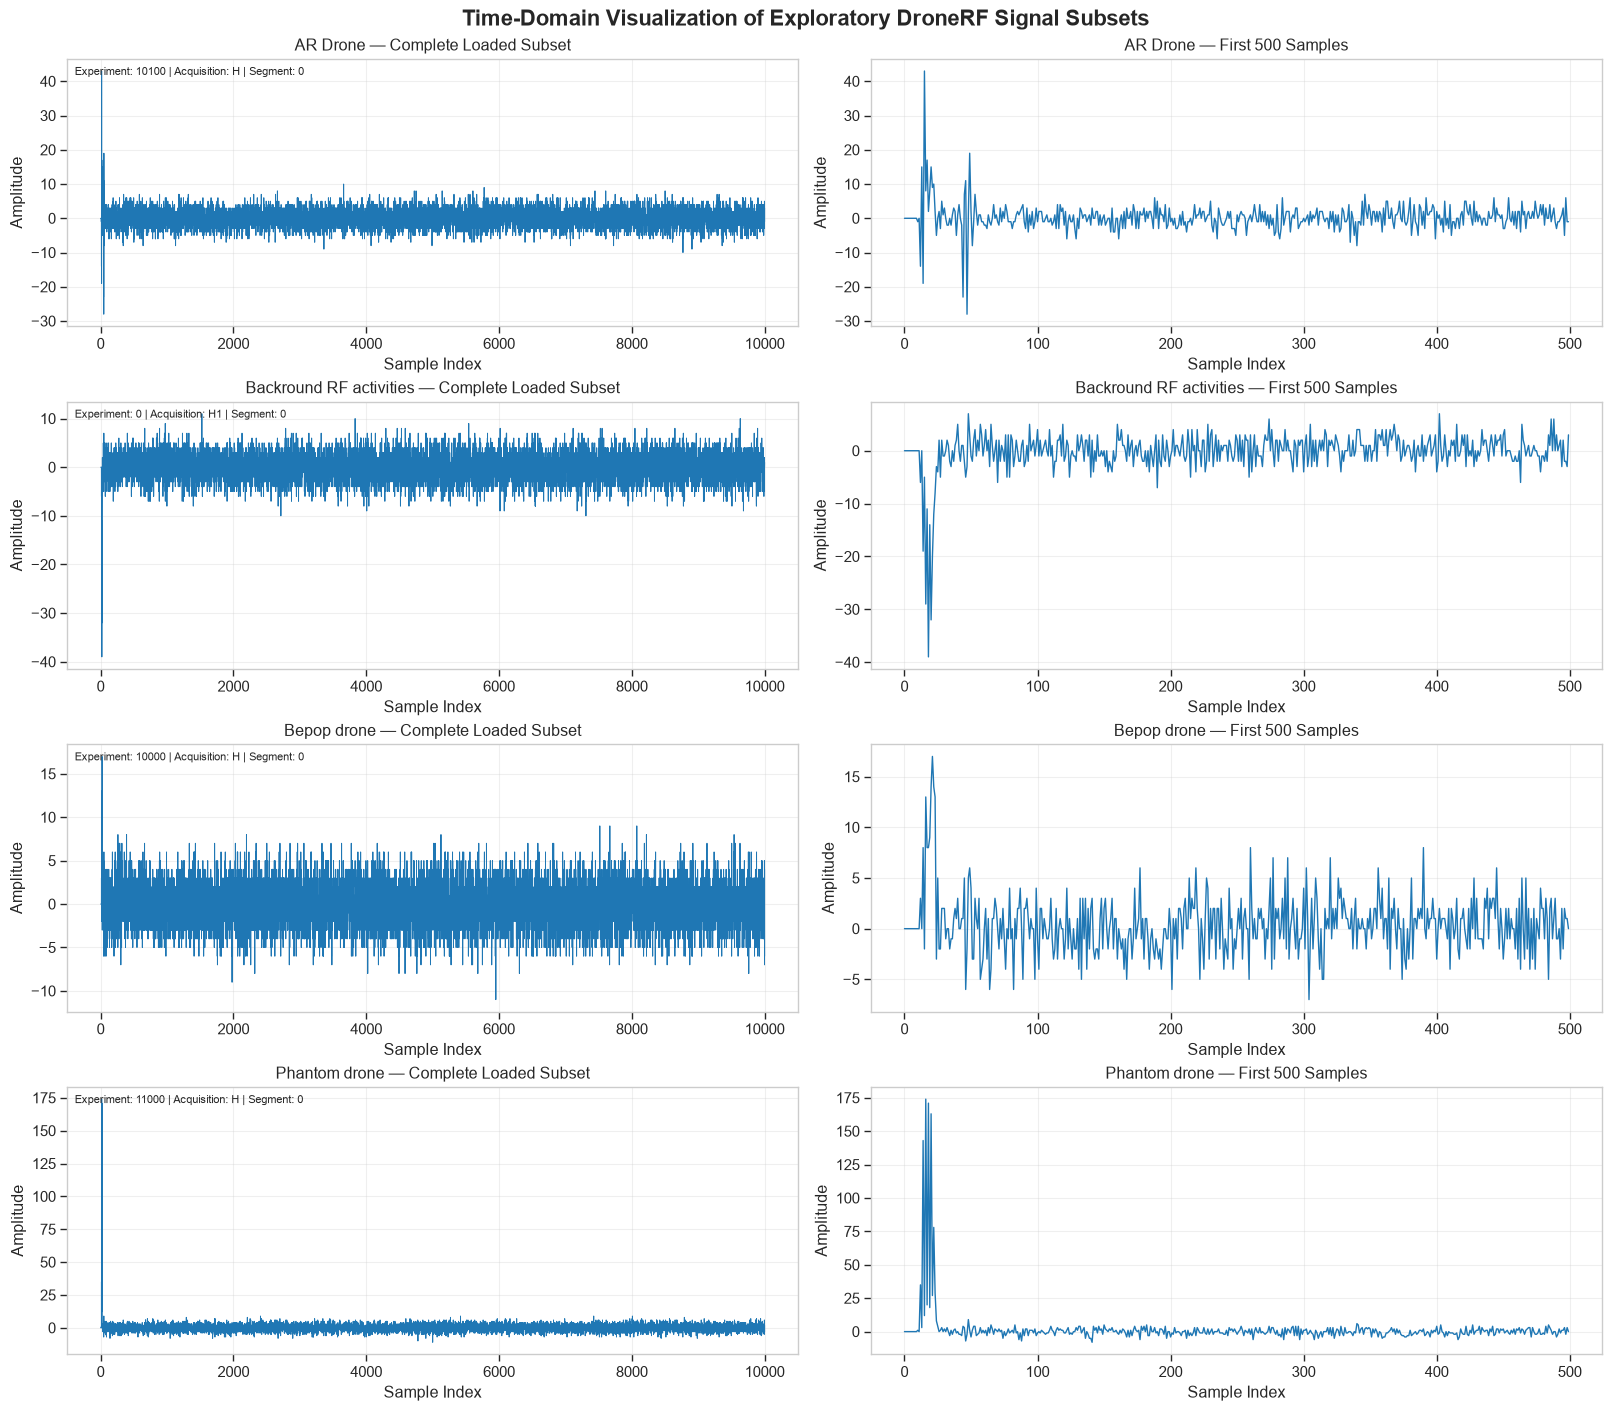

In [50]:
# ============================================================
# Time-Domain Signal Visualization
# ============================================================

print("=== Time-Domain Signal Visualization ===\n")


def plot_time_domain_signals(
    cache: dict,
    zoom_size: int,
    out_dir: Path,
):
    """
    Plot complete and zoomed time-domain views of the selected
    exploratory RF signal subsets.

    Parameters
    ----------
    cache : dict
        Cached RF signals and associated metadata.

    zoom_size : int
        Number of initial samples displayed in the zoomed view.

    out_dir : Path
        Directory in which the generated figure is saved.
    """

    n_classes = len(cache)

    if n_classes == 0:
        raise ValueError("Signal cache is empty.")

    # --------------------------------------------------------
    # Create one row per drone class
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        n_classes,
        2,
        figsize=(16, 3.5 * n_classes),
        constrained_layout=True
    )

    # Ensure consistent indexing if only one class is present
    if n_classes == 1:
        axes = np.array([axes])

    # --------------------------------------------------------
    # Plot each exploratory RF subset
    # --------------------------------------------------------

    for row_idx, (drone_class, data) in enumerate(cache.items()):

        signal_array = data["signal"]
        metadata = data["metadata"]

        n_zoom = min(
            zoom_size,
            signal_array.size
        )

        # ----------------------------------------------------
        # Left: Complete loaded subset
        # ----------------------------------------------------

        ax_full = axes[row_idx, 0]

        ax_full.plot(
            np.arange(signal_array.size),
            signal_array,
            linewidth=0.7
        )

        ax_full.set_title(
            f"{drone_class} — Complete Loaded Subset"
        )

        ax_full.set_xlabel("Sample Index")
        ax_full.set_ylabel("Amplitude")

        ax_full.grid(
            alpha=0.3
        )

        # ----------------------------------------------------
        # Right: Zoomed initial region
        # ----------------------------------------------------

        ax_zoom = axes[row_idx, 1]

        ax_zoom.plot(
            np.arange(n_zoom),
            signal_array[:n_zoom],
            linewidth=1.0
        )

        ax_zoom.set_title(
            f"{drone_class} — First {n_zoom} Samples"
        )

        ax_zoom.set_xlabel("Sample Index")
        ax_zoom.set_ylabel("Amplitude")

        ax_zoom.grid(
            alpha=0.3
        )

        # ----------------------------------------------------
        # Metadata annotation
        # ----------------------------------------------------

        experiment_id = metadata["experiment_id"]
        receiver = metadata["receiver"]
        segment_id = metadata["segment_id"]

        ax_full.text(
            0.01,
            0.97,
            (
                f"Experiment: {experiment_id} | "
                f"Acquisition: {receiver} | "
                f"Segment: {segment_id}"
            ),
            transform=ax_full.transAxes,
            fontsize=8,
            verticalalignment="top"
        )

    # --------------------------------------------------------
    # Figure title
    # --------------------------------------------------------

    fig.suptitle(
        "Time-Domain Visualization of Exploratory DroneRF Signal Subsets",
        fontsize=16,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    figure_path = (
        out_dir /
        "time_domain_exploratory_signals.png"
    )

    fig.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print(
        f"✓ Time-domain figure saved to:\n"
        f"  {figure_path}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate Visualization
# ============================================================

plot_time_domain_signals(
    cache=signal_cache,
    zoom_size=ZOOM_SAMPLES,
    out_dir=NB_FIGURES_DIR,
)

## 10. Distribution Analysis

**Why are we performing this step?**
To analyze the probability distribution and symmetry of RF signal amplitudes.

**What do we expect to observe?**
Histograms, Empirical Cumulative Distribution Functions (ECDF), and grouped Boxplots representing amplitude spread.

**Why is it important?**
Non-Gaussian distributions with heavy tails strongly influence the choice of loss functions and scaling techniques in neural networks.

=== RF Signal Distribution Analysis ===



/var/folders/mx/gw2sdw7x0qs9g7jdnvbvhwyc0000gn/T/ipykernel_34706/2709428914.py:114: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[idx, 2].boxplot(
/var/folders/mx/gw2sdw7x0qs9g7jdnvbvhwyc0000gn/T/ipykernel_34706/2709428914.py:114: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[idx, 2].boxplot(
/var/folders/mx/gw2sdw7x0qs9g7jdnvbvhwyc0000gn/T/ipykernel_34706/2709428914.py:114: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[idx, 2].boxplot(
/var/folders/mx/gw2sdw7x0qs9g7jdnvbvhwyc0000gn/T/ipykernel_34706/2709428914.py:114: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: 

✓ Distribution analysis figure saved to:
  /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/distribution_analysis.png


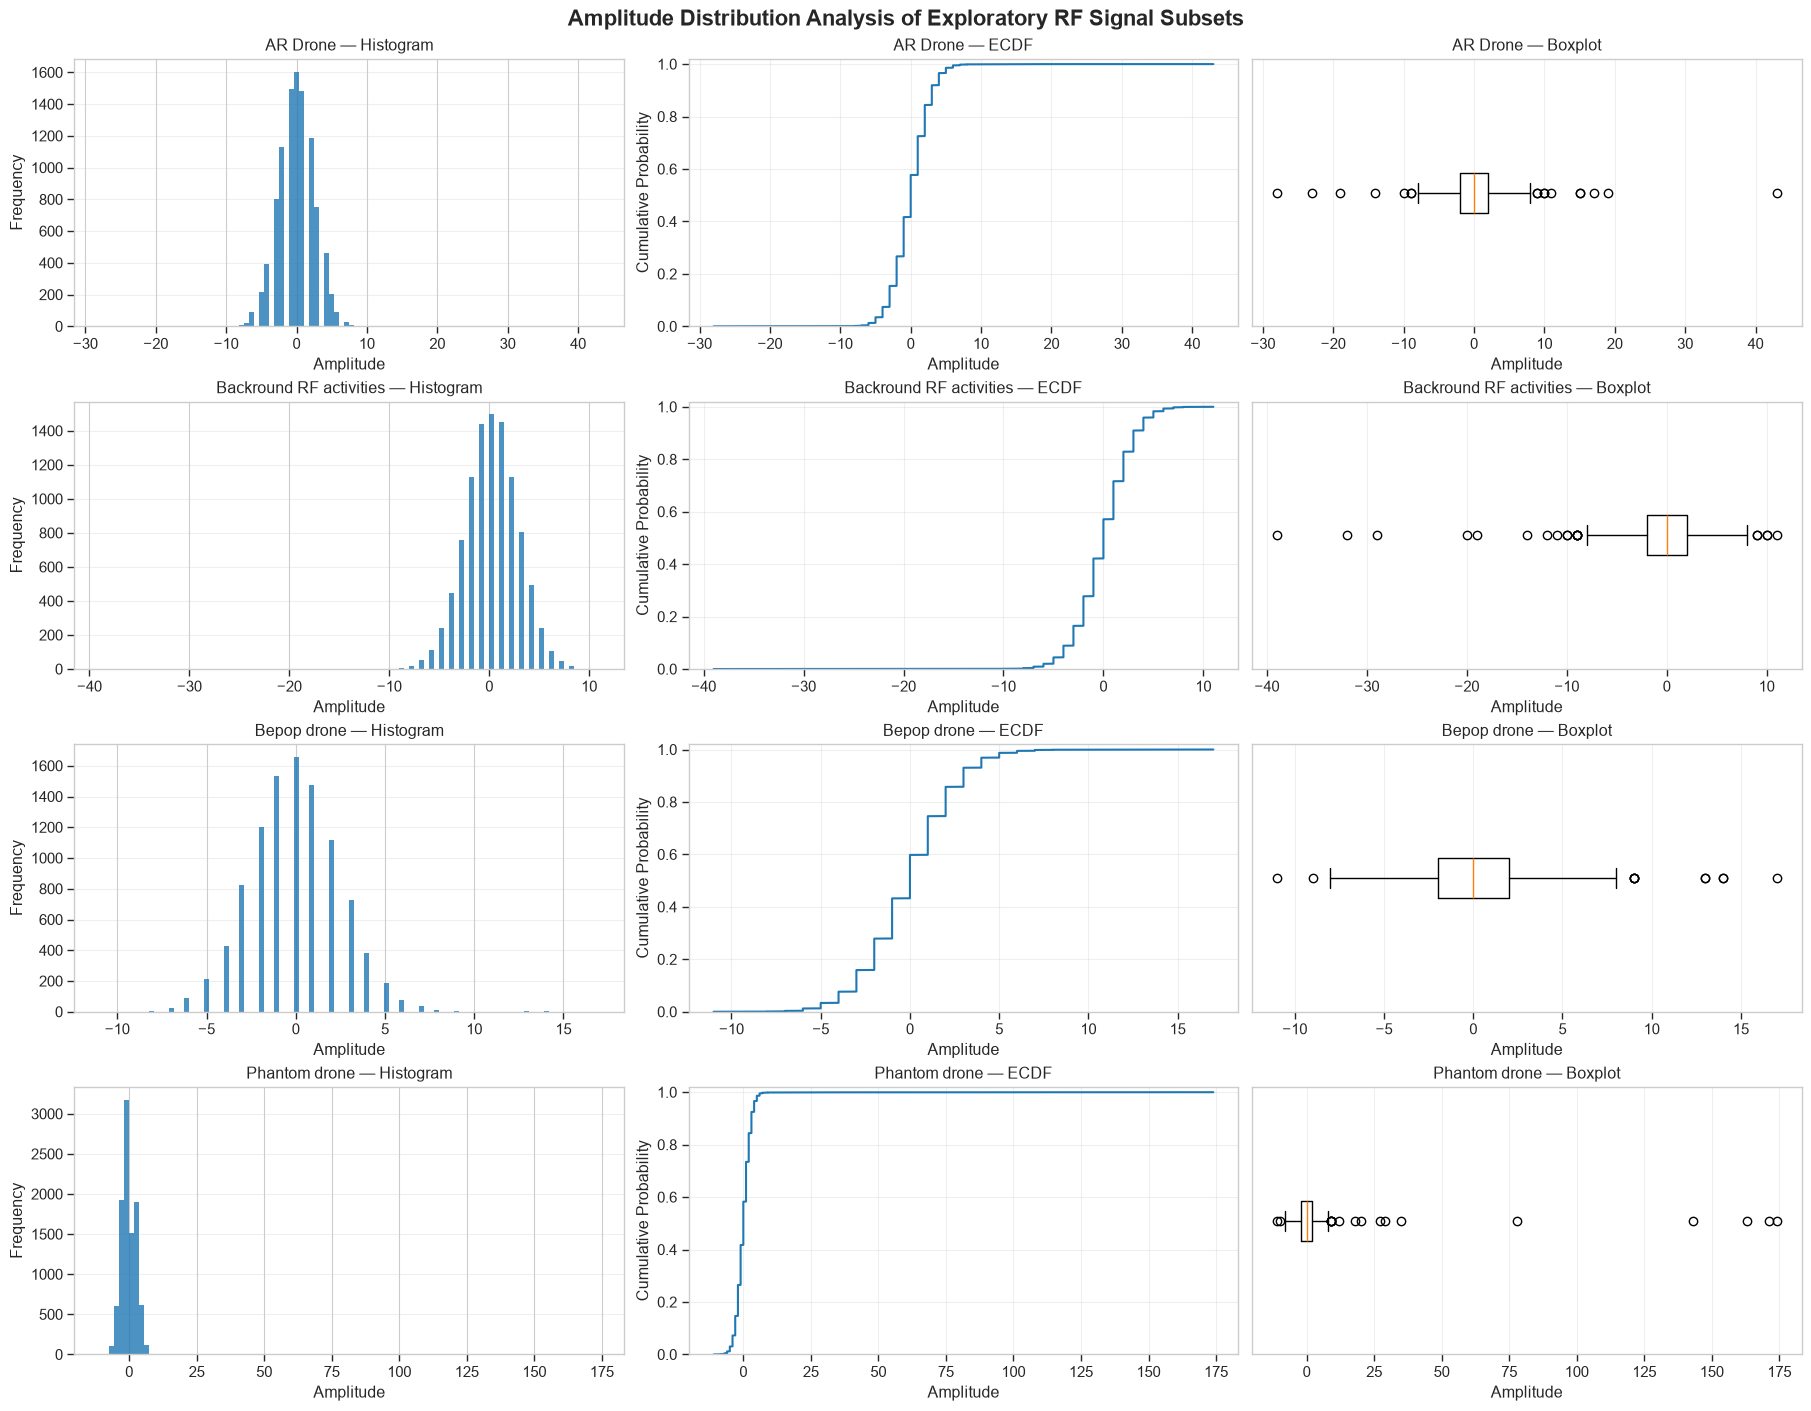

In [51]:
# ============================================================
# Distribution Analysis
# ============================================================

print("=== RF Signal Distribution Analysis ===\n")


def plot_distribution_analysis(
    cache: dict,
    out_dir: Path,
):
    """
    Visualize amplitude distributions of the selected exploratory
    RF signal subsets using histograms, ECDFs, and boxplots.

    Parameters
    ----------
    cache : dict
        Cached RF signals and associated metadata.

    out_dir : Path
        Directory in which the generated figure is saved.
    """

    n_classes = len(cache)

    if n_classes == 0:
        raise ValueError("Signal cache is empty.")

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        n_classes,
        3,
        figsize=(18, 3.5 * n_classes),
        constrained_layout=True
    )

    if n_classes == 1:
        axes = np.array([axes])

    fig.suptitle(
        "Amplitude Distribution Analysis of Exploratory RF Signal Subsets",
        fontsize=16,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Generate plots for each selected signal
    # --------------------------------------------------------

    for idx, (drone_class, data) in enumerate(cache.items()):

        signal_array = data["signal"]

        # ----------------------------------------------------
        # 1. Histogram
        # ----------------------------------------------------

        axes[idx, 0].hist(
            signal_array,
            bins=100,
            alpha=0.8
        )

        axes[idx, 0].set_title(
            f"{drone_class} — Histogram"
        )

        axes[idx, 0].set_xlabel("Amplitude")
        axes[idx, 0].set_ylabel("Frequency")

        axes[idx, 0].grid(
            axis="y",
            alpha=0.3
        )

        # ----------------------------------------------------
        # 2. Empirical Cumulative Distribution Function
        # ----------------------------------------------------

        x_ecdf = np.sort(signal_array)

        y_ecdf = (
            np.arange(1, x_ecdf.size + 1)
            / x_ecdf.size
        )

        axes[idx, 1].plot(
            x_ecdf,
            y_ecdf,
            linewidth=1.5
        )

        axes[idx, 1].set_title(
            f"{drone_class} — ECDF"
        )

        axes[idx, 1].set_xlabel("Amplitude")
        axes[idx, 1].set_ylabel("Cumulative Probability")

        axes[idx, 1].set_ylim(0, 1.02)

        axes[idx, 1].grid(
            alpha=0.3
        )

        # ----------------------------------------------------
        # 3. Boxplot
        # ----------------------------------------------------

        axes[idx, 2].boxplot(
            signal_array,
            vert=False,
            showfliers=True
        )

        axes[idx, 2].set_title(
            f"{drone_class} — Boxplot"
        )

        axes[idx, 2].set_xlabel("Amplitude")
        axes[idx, 2].set_yticks([])

        axes[idx, 2].grid(
            axis="x",
            alpha=0.3
        )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    figure_path = (
        out_dir /
        "distribution_analysis.png"
    )

    fig.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print(
        f"✓ Distribution analysis figure saved to:\n"
        f"  {figure_path}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate Distribution Analysis
# ============================================================

plot_distribution_analysis(
    cache=signal_cache,
    out_dir=NB_FIGURES_DIR
)

## 11. Stationarity Inspection

**Why are we performing this step?**
To visually assess if the signal's mean and variance remain stable (stationary) across the temporal window.

**What do we expect to observe?**
Traces of the rolling mean and rolling variance applied over the signal.

**Why is it important?**
Signals exhibiting high temporal instability (non-stationarity) dictate that static Fourier Transforms are insufficient, necessitating time-frequency methods (STFT).

=== Stationarity Inspection: Rolling Statistics ===

✓ Rolling-statistics figure saved to:
  /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/stationarity_rolling_analysis.png


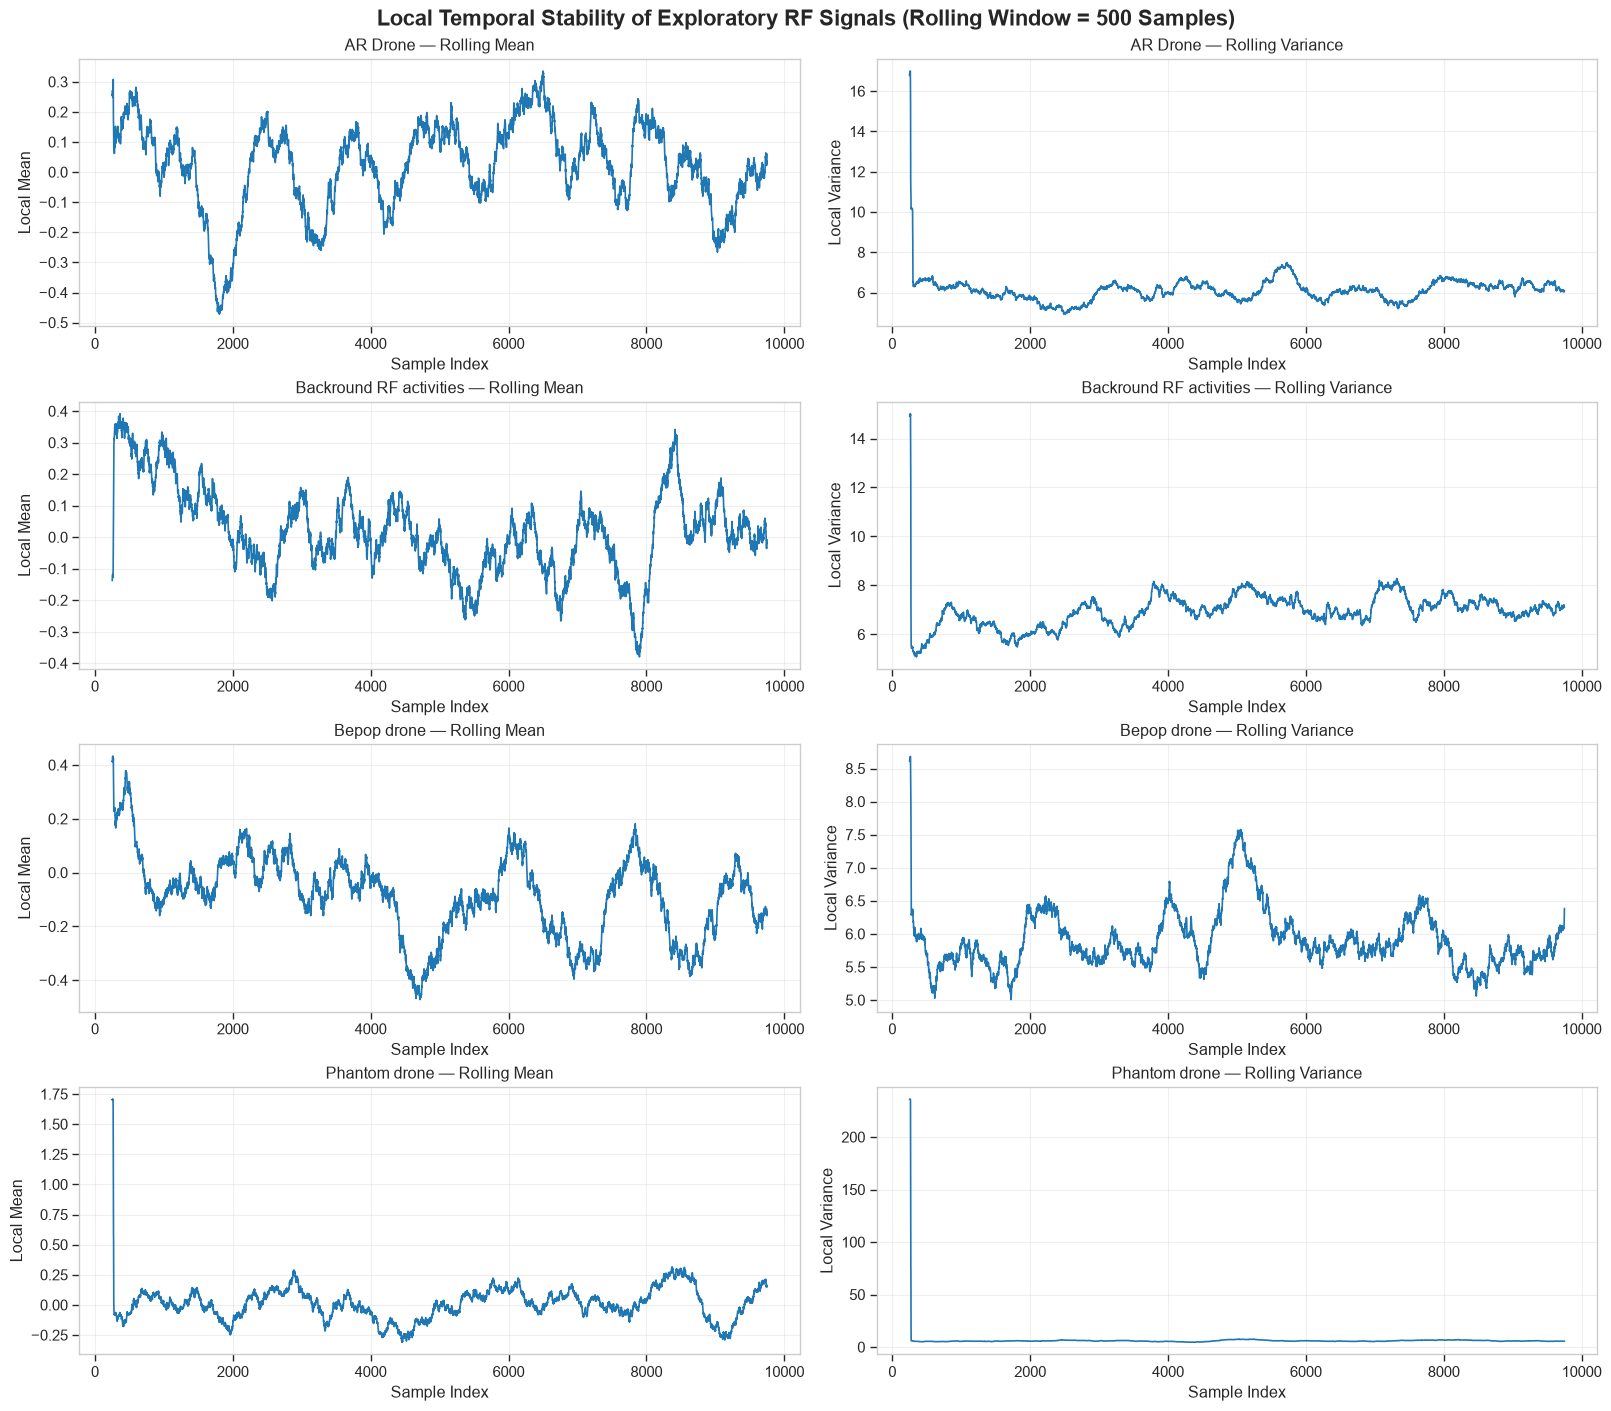

In [53]:
# ============================================================
# Stationarity Inspection — Rolling Statistics
# ============================================================

print("=== Stationarity Inspection: Rolling Statistics ===\n")


def plot_rolling_statistics(
    cache: dict,
    window: int,
    out_dir: Path
):
    """
    Inspect local temporal stability of exploratory RF signal
    subsets using rolling mean and rolling variance.

    Parameters
    ----------
    cache : dict
        Cached exploratory RF signals.

    window : int
        Number of samples used for each rolling window.

    out_dir : Path
        Directory in which the generated figure is saved.
    """

    n_classes = len(cache)

    if n_classes == 0:
        raise ValueError("Signal cache is empty.")

    if window <= 1:
        raise ValueError("Rolling window must be greater than 1.")

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        n_classes,
        2,
        figsize=(16, 3.5 * n_classes),
        constrained_layout=True
    )

    if n_classes == 1:
        axes = np.array([axes])

    fig.suptitle(
        f"Local Temporal Stability of Exploratory RF Signals "
        f"(Rolling Window = {window} Samples)",
        fontsize=16,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Analyze each selected signal
    # --------------------------------------------------------

    for idx, (drone_class, data) in enumerate(cache.items()):

        signal_array = data["signal"]

        if signal_array.size < window:
            raise ValueError(
                f"{drone_class}: signal contains "
                f"{signal_array.size:,} samples, which is smaller "
                f"than the rolling window ({window:,})."
            )

        signal_series = pd.Series(signal_array)

        # Calculate rolling statistics
        rolling_mean = signal_series.rolling(
            window=window,
            center=True,
            min_periods=window
        ).mean()

        rolling_variance = signal_series.rolling(
            window=window,
            center=True,
            min_periods=window
        ).var()

        # ----------------------------------------------------
        # Rolling Mean
        # ----------------------------------------------------

        axes[idx, 0].plot(
            rolling_mean,
            linewidth=1.2
        )

        axes[idx, 0].set_title(
            f"{drone_class} — Rolling Mean"
        )

        axes[idx, 0].set_xlabel("Sample Index")
        axes[idx, 0].set_ylabel("Local Mean")

        axes[idx, 0].grid(alpha=0.3)

        # ----------------------------------------------------
        # Rolling Variance
        # ----------------------------------------------------

        axes[idx, 1].plot(
            rolling_variance,
            linewidth=1.2
        )

        axes[idx, 1].set_title(
            f"{drone_class} — Rolling Variance"
        )

        axes[idx, 1].set_xlabel("Sample Index")
        axes[idx, 1].set_ylabel("Local Variance")

        axes[idx, 1].grid(alpha=0.3)

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    figure_path = (
        out_dir /
        "stationarity_rolling_analysis.png"
    )

    fig.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print(
        f"✓ Rolling-statistics figure saved to:\n"
        f"  {figure_path}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate Stationarity Inspection
# ============================================================

plot_rolling_statistics(
    cache=signal_cache,
    window=ROLLING_WINDOW,
    out_dir=NB_FIGURES_DIR
)

## 12. Augmented Dickey–Fuller Stationarity Test

**Why are we performing this step?**  
To complement the rolling mean and variance inspection with a formal statistical test for unit-root non-stationarity in the exploratory RF signal subsets.

**What do we expect to observe?**  
An ADF statistic and p-value for each selected RF signal subset. At a significance level of 0.05, a p-value below 0.05 provides evidence for rejecting the null hypothesis of a unit root.

**Why is it important?**  
Rolling statistics provide useful visual evidence of local temporal variation, but interpretation can be subjective. The Augmented Dickey–Fuller test provides an additional quantitative assessment of unit-root behavior.

**Interpretation:**  
- **p < 0.05:** Reject the null hypothesis of a unit root.
- **p ≥ 0.05:** Insufficient evidence to reject the unit-root null hypothesis.

Because only one controlled 10,000-sample subset per class is analyzed, these results describe the selected exploratory signals and should not be generalized to every recording in the corresponding drone class.

In [54]:
# ============================================================
# Augmented Dickey-Fuller Stationarity Test
# ============================================================

def compute_adf_tests(cache, max_lag=MAX_LAGS):
    """
    Perform the Augmented Dickey-Fuller test on each exploratory
    RF signal subset.

    The ADF null hypothesis is that the signal contains a unit root.
    """

    adf_records = []

    for drone_class, data in cache.items():

        rf_signal = data["signal"]

        # Perform ADF test using a fixed lag for reproducibility
        result = adfuller(
            rf_signal,
            maxlag=max_lag,
            autolag=None
        )

        adf_statistic = result[0]
        p_value = result[1]

        adf_records.append({
            "Drone Class": drone_class,
            "ADF Statistic": adf_statistic,
            "p-value": p_value,
            "Reject Unit-Root H0 (p < 0.05)": p_value < 0.05
        })

    return pd.DataFrame(adf_records)


# ------------------------------------------------------------
# Run ADF Tests
# ------------------------------------------------------------

adf_df = compute_adf_tests(
    signal_cache,
    max_lag=MAX_LAGS
)

# Improve numerical readability
adf_display = adf_df.copy()

adf_display["ADF Statistic"] = (
    adf_display["ADF Statistic"].round(4)
)

adf_display["p-value"] = (
    adf_display["p-value"].apply(lambda x: f"{x:.3e}")
)

print("=== Augmented Dickey-Fuller Test Results ===\n")

display(adf_display)

print(
    "\nInterpretation: p < 0.05 indicates rejection of the "
    "null hypothesis that the analyzed RF subset contains a unit root."
)

=== Augmented Dickey-Fuller Test Results ===



,Drone Class,ADF Statistic,p-value,Reject Unit-Root H0 (p < 0.05)
0,AR Drone,-14.0112,3.711e-26,True
1,Backround RF activities,-14.2356,1.569e-26,True
2,Bepop drone,-14.6829,3.136e-27,True
3,Phantom drone,-17.9515,2.838e-30,True



Interpretation: p < 0.05 indicates rejection of the null hypothesis that the analyzed RF subset contains a unit root.


### Observation

The Augmented Dickey–Fuller test strongly rejects the unit-root null
hypothesis for all four exploratory RF signal subsets (p < 0.05).

The very small p-values provide strong evidence against unit-root
non-stationarity within the analyzed 10,000-sample windows.

However, the rolling-statistics analysis revealed local fluctuations in
mean and variance, particularly transient behavior in the Phantom drone
subset. Therefore, rejection of the ADF unit-root hypothesis should not
be interpreted as proof of strict stationarity.

These findings apply only to the selected exploratory subsets and are
not generalized to all recordings within each drone class.

## 13. Autocorrelation Analysis

**Why are we performing this step?**
To extract repeating temporal patterns by correlating the signal against delayed copies of itself.

**What do we expect to observe?**
A normalized autocorrelation curve starting at Lag 1 up to `MAX_LAGS`, featuring a zero reference line and 95% confidence bounds.

**Why is it important?**
Periodic signals or distinct transmission intervals uniquely fingerprint drone controller communications in the time domain.

=== Autocorrelation Analysis ===

✓ Autocorrelation figure saved to:
  /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/autocorrelation_analysis.png


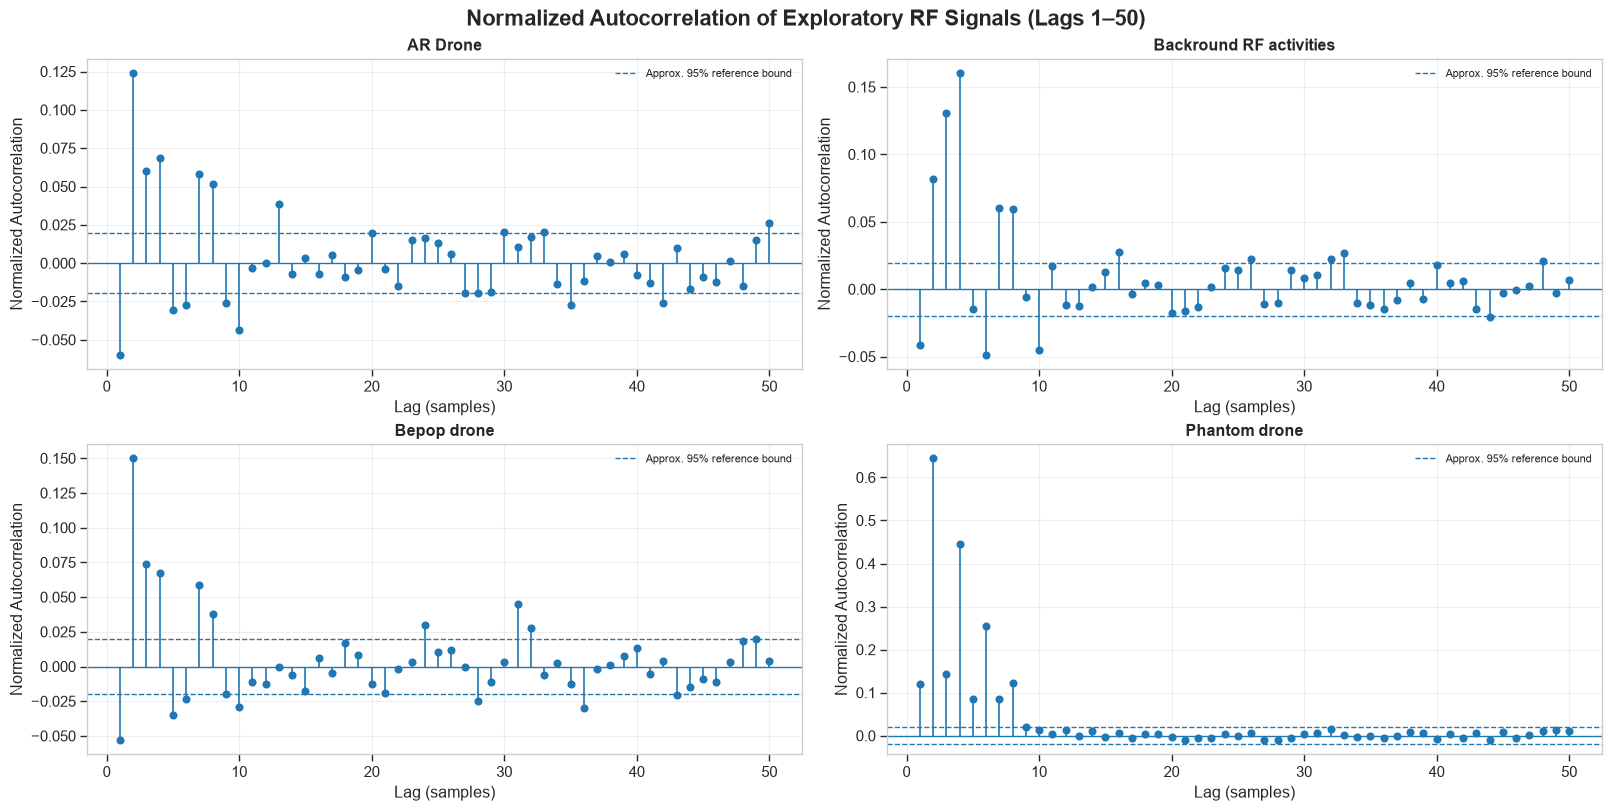

In [55]:
# ============================================================
# Autocorrelation Analysis
# ============================================================

print("=== Autocorrelation Analysis ===\n")


def plot_normalized_autocorrelation(
    cache: dict,
    max_lags: int,
    out_dir: Path
):
    """
    Compute and visualize normalized autocorrelation for each
    exploratory RF signal subset.
    """

    n_classes = len(cache)

    if n_classes == 0:
        raise ValueError("Signal cache is empty.")

    rows = int(np.ceil(n_classes / 2))

    fig, axes = plt.subplots(
        rows,
        2,
        figsize=(16, 4 * rows),
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        f"Normalized Autocorrelation of Exploratory RF Signals "
        f"(Lags 1–{max_lags})",
        fontsize=16,
        fontweight="bold"
    )

    for idx, (drone_class, data) in enumerate(cache.items()):

        rf_signal = np.asarray(
            data["signal"],
            dtype=np.float64
        )

        n_samples = rf_signal.size

        if n_samples <= max_lags:
            raise ValueError(
                f"{drone_class}: signal length ({n_samples}) "
                f"must exceed MAX_LAGS ({max_lags})."
            )

        # ----------------------------------------------------
        # Remove DC component
        # ----------------------------------------------------

        centered_signal = (
            rf_signal - np.mean(rf_signal)
        )

        # ----------------------------------------------------
        # Compute autocorrelation
        # ----------------------------------------------------

        full_acf = np.correlate(
            centered_signal,
            centered_signal,
            mode="full"
        )

        positive_acf = full_acf[
            full_acf.size // 2:
        ]

        lag_zero = positive_acf[0]

        if np.isclose(lag_zero, 0):
            raise ValueError(
                f"{drone_class}: zero signal variance prevents "
                "autocorrelation normalization."
            )

        # Exclude lag 0 because it is always 1 after normalization
        autocorrelation = (
            positive_acf[1:max_lags + 1] /
            lag_zero
        )

        lags = np.arange(
            1,
            max_lags + 1
        )

        # ----------------------------------------------------
        # Approximate 95% reference bounds
        # ----------------------------------------------------

        confidence_bound = (
            1.96 / np.sqrt(n_samples)
        )

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        axes[idx].stem(
            lags,
            autocorrelation,
            basefmt=" "
        )

        axes[idx].axhline(
            0,
            linewidth=1
        )

        axes[idx].axhline(
            confidence_bound,
            linestyle="--",
            linewidth=1,
            label="Approx. 95% reference bound"
        )

        axes[idx].axhline(
            -confidence_bound,
            linestyle="--",
            linewidth=1
        )

        axes[idx].set_title(
            drone_class,
            fontweight="bold"
        )

        axes[idx].set_xlabel("Lag (samples)")
        axes[idx].set_ylabel("Normalized Autocorrelation")

        axes[idx].grid(alpha=0.3)

        axes[idx].legend(
            fontsize=8,
            loc="best"
        )

    # Remove unused axes
    for idx in range(n_classes, len(axes)):
        fig.delaxes(axes[idx])

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    figure_path = (
        out_dir /
        "autocorrelation_analysis.png"
    )

    fig.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print(
        f"✓ Autocorrelation figure saved to:\n"
        f"  {figure_path}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate Autocorrelation Analysis
# ============================================================

plot_normalized_autocorrelation(
    cache=signal_cache,
    max_lags=MAX_LAGS,
    out_dir=NB_FIGURES_DIR
)

### Observation

The autocorrelation analysis reveals measurable short-range temporal
dependence in all four exploratory RF signal subsets.

AR Drone, Background RF activities, and Bepop drone exhibit several
positive and negative autocorrelation coefficients exceeding the
approximate reference bounds at short lags. Their correlations generally
decrease in magnitude as lag increases.

The selected Phantom drone subset exhibits substantially stronger
short-range autocorrelation, with prominent positive coefficients at
several early lags followed by rapid decay toward zero. This behavior
is consistent with the pronounced transient structure previously observed
in its time-domain and rolling-statistics analyses.

These results indicate that the selected RF sequences are not composed
of completely independent adjacent samples and contain short-range
temporal structure. However, the observed differences should not yet
be interpreted as class-specific RF fingerprints because only one
exploratory subset per class is being examined.

## 14. Frequency Domain Analysis (FFT)

**Why are we performing this step?**
To isolate the dominant frequency components constituting the RF signal.

**What do we expect to observe?**
A Log Magnitude Spectrum (dB) plotted across normalized frequencies.

**Why is it important?**
Hardware signatures (e.g., specific carrier waves or hopping centers) manifest distinctly as power peaks in the frequency domain.

=== FFT Frequency-Domain Analysis ===

✓ FFT analysis completed successfully.
✓ Figure saved to:
  /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/fft_analysis.png


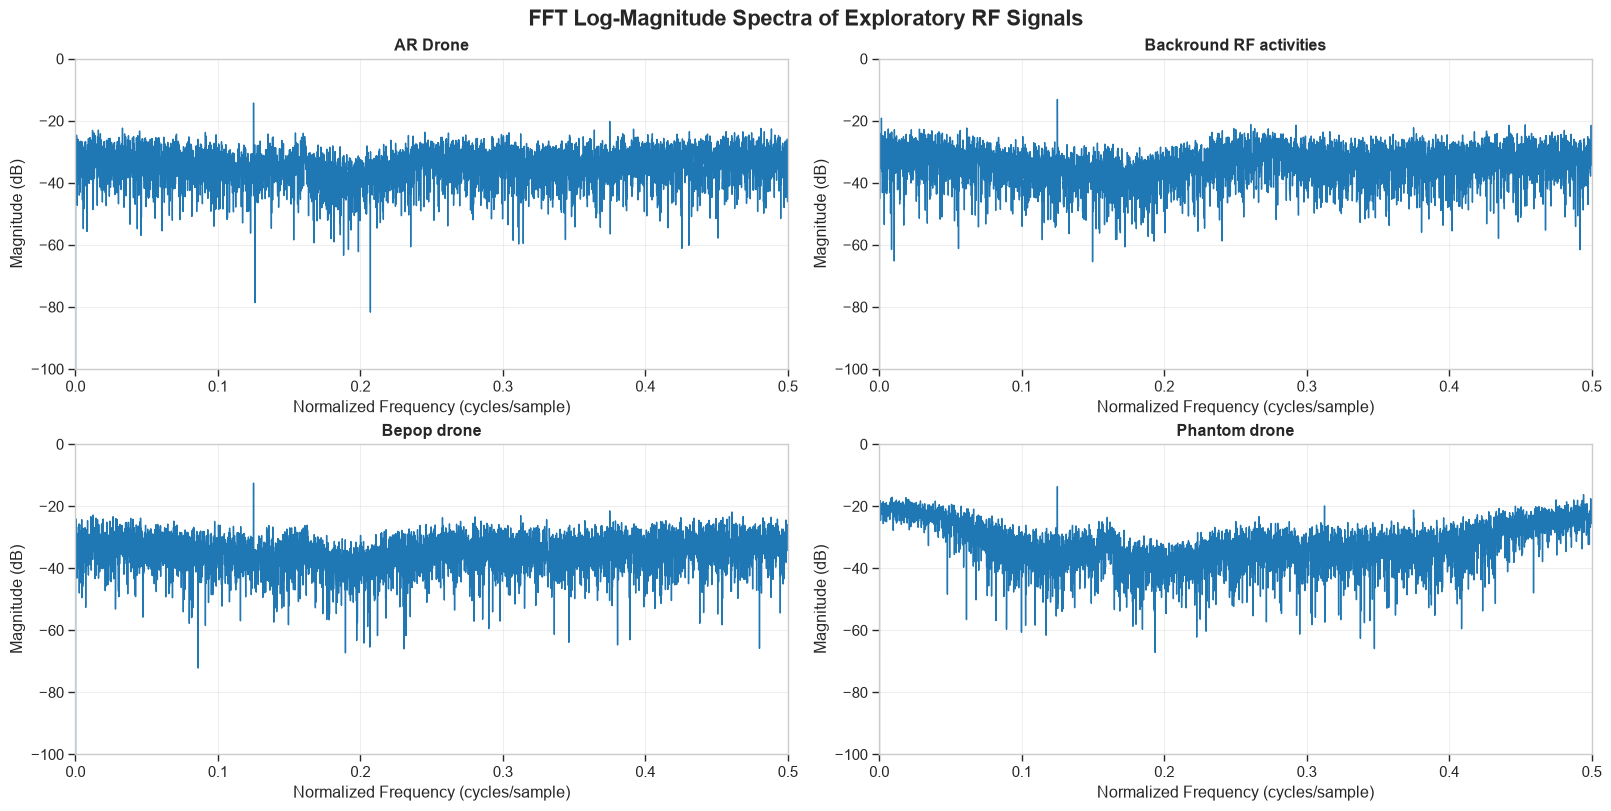

In [57]:
# ============================================================
# FFT Frequency-Domain Analysis
# ============================================================

print("=== FFT Frequency-Domain Analysis ===\n")


def plot_fft_log_spectrum(cache: dict, out_dir: Path):
    """
    Compute and visualize the one-sided FFT log-magnitude spectrum
    for each exploratory RF signal subset.

    Frequency is expressed in cycles/sample because the physical
    sampling frequency is not currently incorporated into the analysis.
    """

    n_classes = len(cache)

    if n_classes == 0:
        raise ValueError("Signal cache is empty.")

    rows = int(np.ceil(n_classes / 2))

    fig, axes = plt.subplots(
        rows,
        2,
        figsize=(16, 4 * rows),
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        "FFT Log-Magnitude Spectra of Exploratory RF Signals",
        fontsize=16,
        fontweight="bold"
    )

    for idx, (drone_class, data) in enumerate(cache.items()):

        # ----------------------------------------------------
        # Retrieve signal
        # ----------------------------------------------------

        rf_signal = np.asarray(
            data["signal"],
            dtype=np.float64
        )

        n_samples = rf_signal.size

        if n_samples == 0:
            raise ValueError(
                f"{drone_class}: signal is empty."
            )

        # ----------------------------------------------------
        # Remove DC component
        # ----------------------------------------------------

        centered_signal = (
            rf_signal - np.mean(rf_signal)
        )

        # ----------------------------------------------------
        # Compute one-sided FFT
        # ----------------------------------------------------

        fft_values = np.fft.rfft(
            centered_signal
        )

        # Normalize magnitude by signal length
        fft_magnitude = (
            np.abs(fft_values) / n_samples
        )

        # ----------------------------------------------------
        # Construct normalized frequency axis
        #
        # d = 1.0 means frequency is expressed in
        # cycles/sample rather than physical Hz.
        #
        # Nyquist frequency = 0.5 cycles/sample.
        # ----------------------------------------------------

        frequencies = np.fft.rfftfreq(
            n_samples,
            d=1.0
        )

        # ----------------------------------------------------
        # Convert magnitude to decibels
        # ----------------------------------------------------

        epsilon = np.finfo(np.float64).eps

        fft_db = 20 * np.log10(
            fft_magnitude + epsilon
        )

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        ax = axes[idx]

        ax.plot(
            frequencies,
            fft_db,
            linewidth=1
        )

        ax.set_title(
            drone_class,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Normalized Frequency (cycles/sample)"
        )

        ax.set_ylabel(
            "Magnitude (dB)"
        )

        # One-sided normalized frequency range
        ax.set_xlim(0, 0.5)

        # Prevent the near-zero DC bin from stretching
        # the visualization to approximately -300 dB.
        # This affects visualization only, not FFT values.
        ax.set_ylim(-100, 0)

        ax.grid(
            alpha=0.3
        )

    # --------------------------------------------------------
    # Remove unused subplot axes
    # --------------------------------------------------------

    for idx in range(n_classes, len(axes)):
        fig.delaxes(axes[idx])

    # --------------------------------------------------------
    # Save publication-quality figure
    # --------------------------------------------------------

    figure_path = (
        out_dir /
        "fft_analysis.png"
    )

    fig.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print(
        "✓ FFT analysis completed successfully."
    )

    print(
        f"✓ Figure saved to:\n  {figure_path}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate FFT Analysis
# ============================================================

plot_fft_log_spectrum(
    cache=signal_cache,
    out_dir=NB_FIGURES_DIR
)

### Observation

The FFT analysis shows broadband spectral content across the analyzed
normalized-frequency range for all four exploratory RF signal subsets.

The AR Drone, Background RF activities, and Bepop drone subsets exhibit
relatively broad spectra without a single strongly dominant spectral
component in the selected 10,000-sample windows.

The selected Phantom drone subset exhibits a visibly different spectral
envelope. This observation is consistent with its previously observed
time-domain transient behavior and stronger short-range autocorrelation.

These spectral differences demonstrate that the selected exploratory
signals contain different frequency-domain characteristics. However,
because only one controlled subset per class is analyzed, the observed
spectra should not be interpreted as general class-specific signatures.

Frequency is reported in cycles per sample because the physical sampling
frequency has not yet been incorporated into this analysis.

## 15. Power Spectral Density (PSD)

**Why are we performing this step?**
To accurately estimate the distribution of power across the frequency spectrum using Welch’s overlapping segment method.

**What do we expect to observe?**
A smoothed frequency response plot demonstrating absolute power density.

**Why is it important?**
Welch's method significantly reduces the variance (noise) typical in standard FFT periodograms, providing cleaner boundaries for frequency filtering.

=== Welch Power Spectral Density Analysis ===

✓ Welch PSD analysis completed successfully.
✓ Figure saved to:
  /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/welch_psd_analysis.png


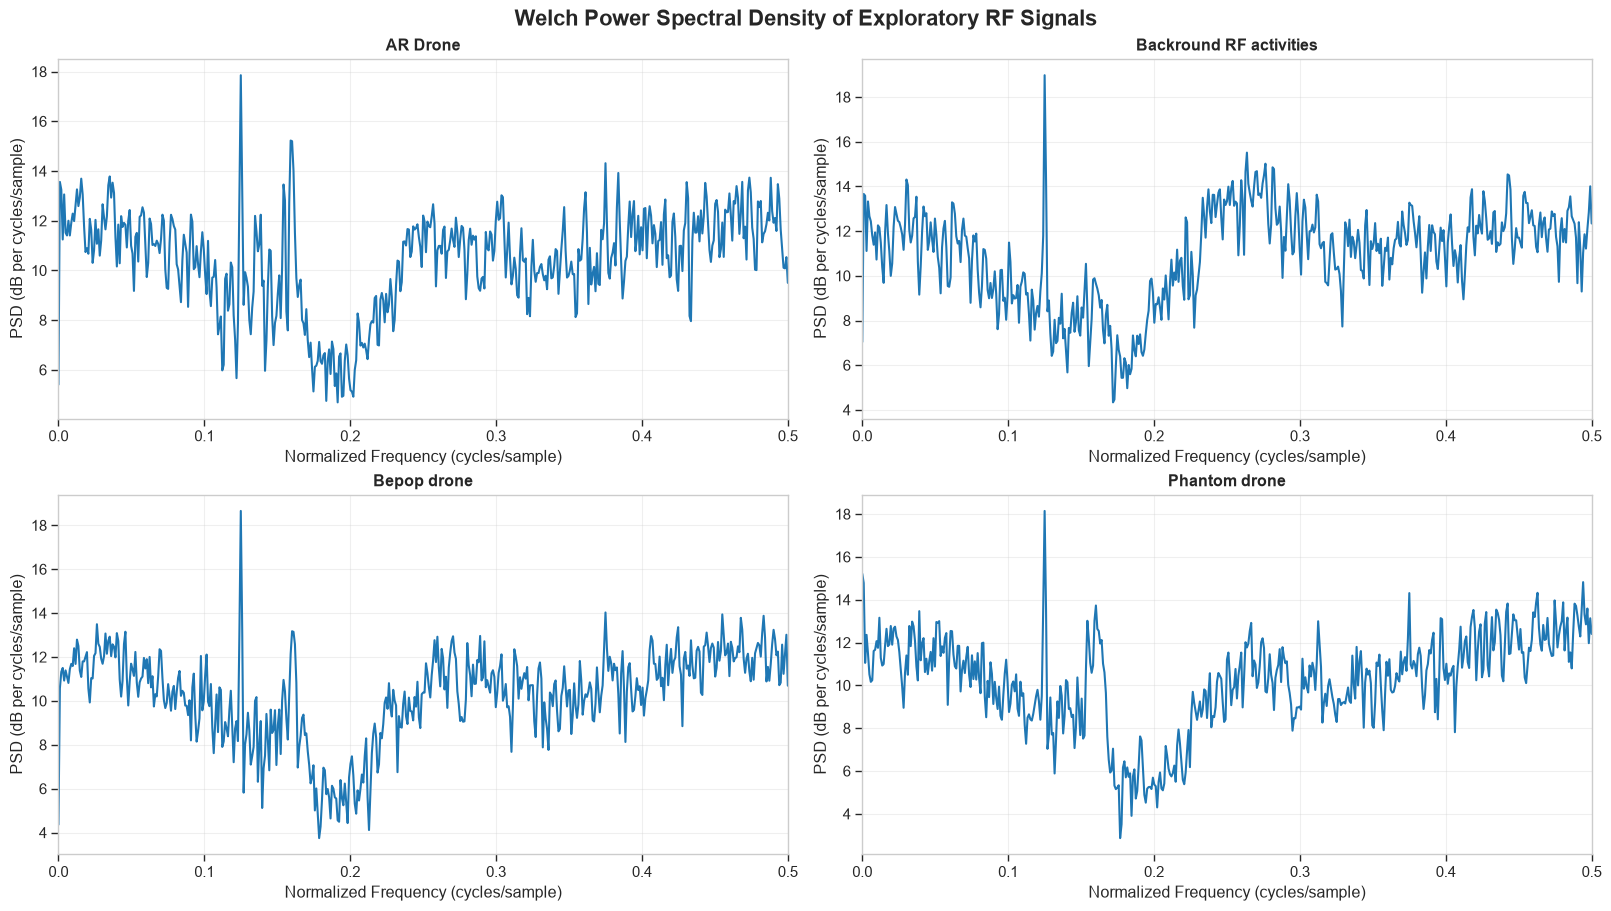

In [58]:
# ============================================================
# Power Spectral Density Analysis — Welch's Method
# ============================================================

print("=== Welch Power Spectral Density Analysis ===\n")


def plot_welch_psd(
    cache: dict,
    output_dir: Path,
    nperseg: int = 1024
):
    """
    Compute and visualize Welch PSD estimates for each
    exploratory RF signal subset.

    Frequency is expressed in cycles/sample because the physical
    sampling frequency is not currently incorporated into the analysis.
    """

    num_classes = len(cache)

    if num_classes == 0:
        raise ValueError("Signal cache is empty.")

    rows = int(np.ceil(num_classes / 2))

    fig, axes = plt.subplots(
        rows,
        2,
        figsize=(16, 4.5 * rows),
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        "Welch Power Spectral Density of Exploratory RF Signals",
        fontsize=16,
        fontweight="bold"
    )

    for index, (drone_class, signal_info) in enumerate(cache.items()):

        # ----------------------------------------------------
        # Retrieve signal
        # ----------------------------------------------------

        rf_signal = np.asarray(
            signal_info["signal"],
            dtype=np.float64
        )

        if rf_signal.size == 0:
            raise ValueError(
                f"{drone_class}: signal is empty."
            )

        # ----------------------------------------------------
        # Remove global DC component
        # ----------------------------------------------------

        centered_signal = (
            rf_signal - np.mean(rf_signal)
        )

        # ----------------------------------------------------
        # Welch PSD
        #
        # fs=1.0 gives normalized frequency in cycles/sample.
        # ----------------------------------------------------

        segment_length = min(
            nperseg,
            centered_signal.size
        )

        frequencies, psd = welch(
            centered_signal,
            fs=1.0,
            window="hann",
            nperseg=segment_length,
            noverlap=segment_length // 2,
            detrend="constant",
            scaling="density"
        )

        # ----------------------------------------------------
        # Convert PSD to logarithmic scale
        # ----------------------------------------------------

        epsilon = np.finfo(np.float64).tiny

        psd_db = 10 * np.log10(
            psd + epsilon
        )

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        ax = axes[index]

        ax.plot(
            frequencies,
            psd_db,
            linewidth=1.5
        )

        ax.set_title(
            drone_class,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Normalized Frequency (cycles/sample)"
        )

        ax.set_ylabel(
            "PSD (dB per cycles/sample)"
        )

        ax.set_xlim(
            0,
            0.5
        )

        ax.grid(
            alpha=0.3
        )

    # --------------------------------------------------------
    # Remove unused axes
    # --------------------------------------------------------

    for index in range(num_classes, len(axes)):
        fig.delaxes(axes[index])

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    figure_path = (
        output_dir /
        "welch_psd_analysis.png"
    )

    fig.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print("✓ Welch PSD analysis completed successfully.")

    print(
        f"✓ Figure saved to:\n"
        f"  {figure_path}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate Welch PSD Analysis
# ============================================================

plot_welch_psd(
    cache=signal_cache,
    output_dir=NB_FIGURES_DIR,
    nperseg=1024
)

## 16. Spectrogram Analysis

**Why are we performing this step?**
To observe time-frequency evolution mapping non-stationary shifts in the RF sequence.

**What do we expect to observe?**
A Short-Time Fourier Transform (STFT) heatmap displaying time, frequency, and spectral density.

**Why is it important?**
Time-independent spectral analyses (FFT/PSD) obscure frequency hopping. STFT explicitly tracks how frequency bounds evolve.

=== Spectrogram Analysis ===

✓ Spectrogram analysis completed successfully.
✓ Figure saved to:
  /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/spectrogram_analysis.png


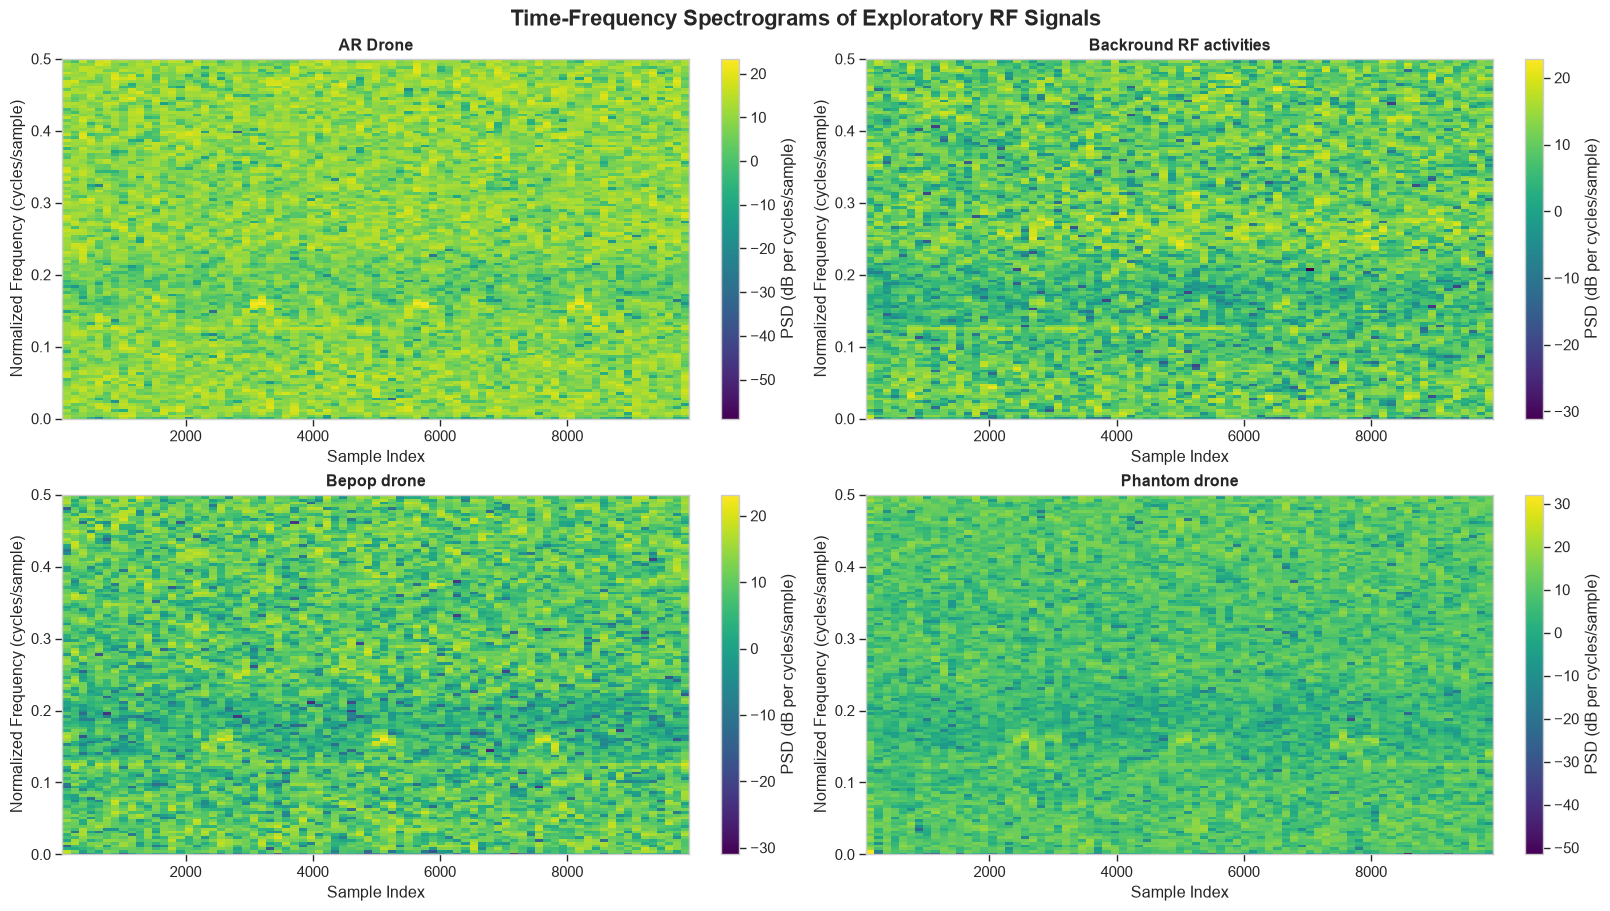

In [59]:
# ============================================================
# Time-Frequency Analysis — Spectrogram
# ============================================================

print("=== Spectrogram Analysis ===\n")


def plot_spectrogram(
    cache: dict,
    out_dir: Path,
    nperseg: int = 256,
    noverlap: int = 128
):
    """
    Generate spectrograms for exploratory RF signal subsets.

    Frequency is expressed in cycles/sample because the physical
    sampling frequency is not currently incorporated into the analysis.
    """

    n_classes = len(cache)

    if n_classes == 0:
        raise ValueError("Signal cache is empty.")

    rows = int(np.ceil(n_classes / 2))

    fig, axes = plt.subplots(
        rows,
        2,
        figsize=(16, 4.5 * rows),
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        "Time-Frequency Spectrograms of Exploratory RF Signals",
        fontsize=16,
        fontweight="bold"
    )

    for idx, (drone_class, data) in enumerate(cache.items()):

        # ----------------------------------------------------
        # Retrieve signal
        # ----------------------------------------------------

        rf_signal = np.asarray(
            data["signal"],
            dtype=np.float64
        )

        if rf_signal.size == 0:
            raise ValueError(
                f"{drone_class}: signal is empty."
            )

        # ----------------------------------------------------
        # Remove global DC component
        # ----------------------------------------------------

        centered_signal = (
            rf_signal - np.mean(rf_signal)
        )

        # ----------------------------------------------------
        # Configure STFT window
        # ----------------------------------------------------

        segment_length = min(
            nperseg,
            centered_signal.size
        )

        overlap_length = min(
            noverlap,
            segment_length - 1
        )

        # ----------------------------------------------------
        # Compute spectrogram
        #
        # fs=1.0 means:
        # frequency -> cycles/sample
        # time      -> sample units
        # ----------------------------------------------------

        frequencies, sample_positions, Sxx = signal.spectrogram(
            centered_signal,
            fs=1.0,
            window="hann",
            nperseg=segment_length,
            noverlap=overlap_length,
            detrend="constant",
            scaling="density",
            mode="psd"
        )

        # Convert spectrogram time coordinates to sample index
        sample_positions = (
            sample_positions * 1.0
        )

        # ----------------------------------------------------
        # Convert power to dB
        # ----------------------------------------------------

        epsilon = np.finfo(np.float64).tiny

        Sxx_db = 10 * np.log10(
            Sxx + epsilon
        )

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        ax = axes[idx]

        mesh = ax.pcolormesh(
            sample_positions,
            frequencies,
            Sxx_db,
            shading="auto",
            cmap="viridis"
        )

        ax.set_title(
            drone_class,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Sample Index"
        )

        ax.set_ylabel(
            "Normalized Frequency (cycles/sample)"
        )

        ax.set_ylim(
            0,
            0.5
        )

        colorbar = fig.colorbar(
            mesh,
            ax=ax
        )

        colorbar.set_label(
            "PSD (dB per cycles/sample)"
        )

    # --------------------------------------------------------
    # Remove unused axes
    # --------------------------------------------------------

    for idx in range(n_classes, len(axes)):
        fig.delaxes(axes[idx])

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    figure_path = (
        out_dir /
        "spectrogram_analysis.png"
    )

    fig.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print("✓ Spectrogram analysis completed successfully.")

    print(
        f"✓ Figure saved to:\n"
        f"  {figure_path}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate Spectrogram Analysis
# ============================================================

plot_spectrogram(
    cache=signal_cache,
    out_dir=NB_FIGURES_DIR,
    nperseg=256,
    noverlap=128
)

## 17. Cross-Class Comparison

**Why are we performing this step?**
To contrast overarching statistical features across disparate drone profiles side-by-side.

**What do we expect to observe?**
Grouped graphical alignments of multi-class summary statistics.

**Why is it important?**
Determining class separability relies on identifying distinct clustering or distinct variance spreads between models.

=== Cross-Class Statistical Comparison ===

✓ Cross-class exploratory comparison completed.
✓ Figure saved to:
  /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/cross_class_statistical_comparison.png


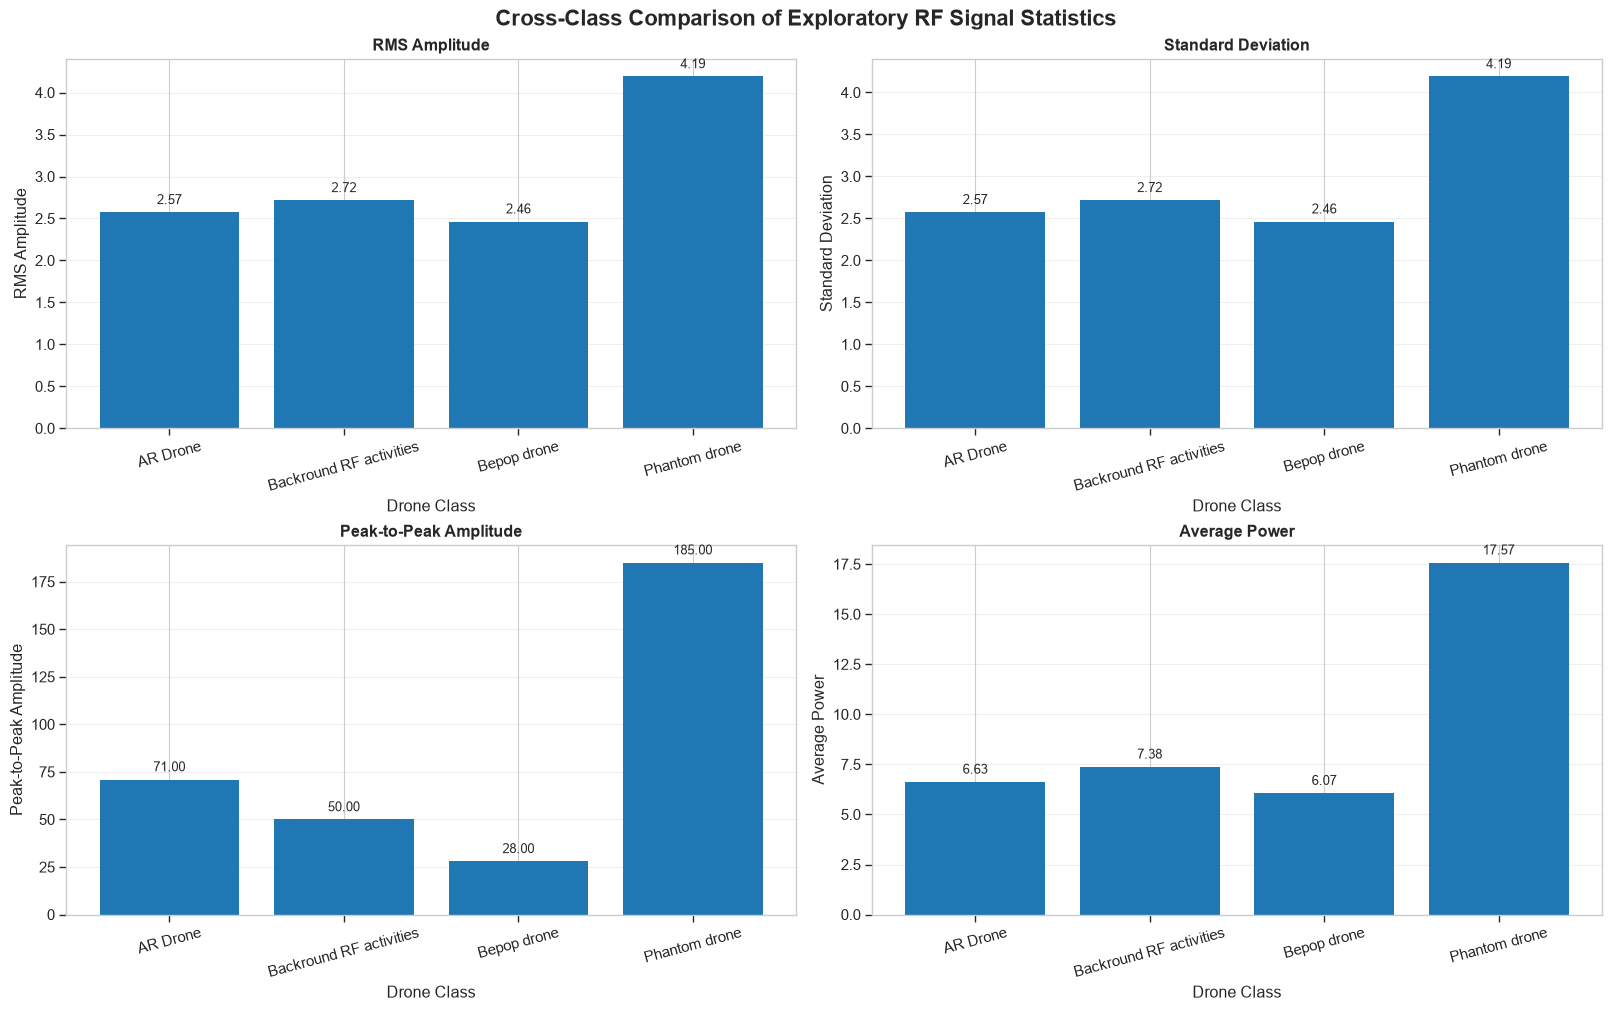

In [61]:
# ============================================================
# Cross-Class Exploratory Statistical Comparison
# ============================================================

print("=== Cross-Class Statistical Comparison ===\n")


def plot_cross_class_comparison(
    stats_df: pd.DataFrame,
    out_dir: Path
):
    """
    Compare selected descriptive statistics across the
    exploratory RF signal subsets.

    These values describe only the selected 10,000-sample
    subsets and are not estimates of complete class distributions.
    """

    if stats_df.empty:
        raise ValueError("Statistics DataFrame is empty.")

    # --------------------------------------------------------
    # Statistics selected for comparison
    # --------------------------------------------------------

    metrics = [
        ("RMS", "RMS Amplitude"),
        ("Std Dev", "Standard Deviation"),
        ("Peak-to-Peak", "Peak-to-Peak Amplitude"),
        ("Average Power", "Average Power")
    ]

    required_columns = [metric[0] for metric in metrics]

    missing_columns = [
        column
        for column in required_columns
        if column not in stats_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required statistics: {missing_columns}"
        )

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10),
        constrained_layout=True
    )

    axes = axes.flatten()

    fig.suptitle(
        "Cross-Class Comparison of Exploratory RF Signal Statistics",
        fontsize=16,
        fontweight="bold"
    )

    class_names = stats_df.index.astype(str)

    # --------------------------------------------------------
    # Plot each statistic
    # --------------------------------------------------------

    for ax, (column, title) in zip(axes, metrics):

        values = stats_df[column].astype(float)

        bars = ax.bar(
            class_names,
            values
        )

        ax.set_title(
            title,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Drone Class"
        )

        ax.set_ylabel(
            title
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        ax.tick_params(
            axis="x",
            rotation=15
        )

        # ----------------------------------------------------
        # Add value labels
        # ----------------------------------------------------

        for bar in bars:

            height = bar.get_height()

            ax.annotate(
                f"{height:.2f}",
                xy=(
                    bar.get_x() + bar.get_width() / 2,
                    height
                ),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9
            )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    figure_path = (
        out_dir /
        "cross_class_statistical_comparison.png"
    )

    fig.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print(
        "✓ Cross-class exploratory comparison completed."
    )

    print(
        f"✓ Figure saved to:\n"
        f"  {figure_path}"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# Generate Comparison
# ============================================================

plot_cross_class_comparison(
    stats_df=statistics_df,
    out_dir=NB_FIGURES_DIR
)

### Observation

The cross-class comparison reveals substantial differences among the
selected exploratory RF signal subsets.

The selected Phantom drone subset exhibits the highest RMS amplitude,
standard deviation, peak-to-peak amplitude, and average power. In
particular, its peak-to-peak amplitude is substantially larger than those
of the other analyzed subsets, consistent with the transient and
high-amplitude behavior observed during the earlier time-domain analysis.

The AR Drone, Background RF activities, and Bebop drone subsets exhibit
more comparable RMS amplitude, standard deviation, and average power,
although differences remain in their observed peak-to-peak ranges.

These results demonstrate that the selected exploratory subsets differ in
several time-domain magnitude characteristics. However, because only one
10,000-sample subset from each class is analyzed, the comparison does not
establish class-level statistical differences or class separability.
Analysis across multiple recordings would be required for such conclusions.

## 18. Key Findings

**Why are we performing this step?**  
To synthesize the principal observations obtained from the exploratory
statistical, temporal, and frequency-domain analyses.

**What do we expect to observe?**  
A concise summary of the signal characteristics identified across the
selected 10,000-sample RF subsets.

**Why is it important?**  
These observations provide evidence for selecting appropriate preprocessing
and feature-extraction methods in subsequent notebooks while clearly
separating exploratory findings from class-level conclusions.

### Analytical Observations

- **Signal integrity:** All four selected RF subsets were successfully loaded
  as one-dimensional numeric arrays without missing or infinite values,
  providing valid inputs for the subsequent analyses.

- **Amplitude characteristics:** The selected subsets exhibit differences in
  RMS amplitude, variance, peak-to-peak range, and average power. The selected
  Phantom drone subset shows particularly large amplitude excursions and
  higher power relative to the other analyzed subsets.

- **Local temporal behavior:** Rolling mean and variance reveal time-varying
  local signal statistics within the analyzed windows. These local
  fluctuations coexist with the ADF results, which reject the unit-root null
  hypothesis for all four selected subsets.

- **Autocorrelation:** Short-lag dependence is present in all analyzed
  subsets, with the selected Phantom drone subset exhibiting especially strong
  short-range autocorrelation. These differences indicate temporal structure
  worthy of further investigation across additional recordings.

- **Frequency-domain structure:** FFT and Welch PSD analyses reveal broadband
  spectral content together with localized spectral features in the selected
  subsets. Differences are visible between the exploratory signals, but the
  current analysis does not establish class-level spectral separability.

- **Time-frequency behavior:** Spectrogram analysis shows predominantly
  broadband activity with localized variations in spectral power over sample
  position. No definitive frequency-hopping pattern is established from the
  selected subsets.

- **Scope of inference:** Because the analysis uses one controlled
  10,000-sample subset per class, all comparisons are exploratory. Multiple
  recordings and experiments must be analyzed before making conclusions about
  class distributions, statistical separability, or classification
  performance.

## 19. Notebook Summary

**Why are we performing this step?**  
To conclude the exploratory RF signal characterization stage and document the
evidence carried forward into subsequent preprocessing and feature-engineering
experiments.

**What do we expect to observe?**  
A concise summary of the analyses completed, their principal observations,
their limitations, and the resulting direction for the next stage.

**Why is it important?**  
Clearly documenting both findings and limitations prevents exploratory
observations from being interpreted as validated class-level conclusions and
provides a reproducible transition to the next stage of the research pipeline.

### Conclusion

This notebook performed exploratory statistical, time-domain,
frequency-domain, and time-frequency characterization of controlled RF signal
subsets selected from the DroneRF metadata index.

The analysis included numerical validation, descriptive statistics, waveform
inspection, amplitude-distribution analysis, rolling statistics, the
Augmented Dickey-Fuller test, autocorrelation, FFT magnitude spectra, Welch
power spectral density estimation, spectrogram analysis, and cross-subset
statistical comparison.

The selected RF subsets exhibit measurable differences in amplitude behavior,
short-range temporal dependence, spectral structure, and local
time-frequency power. The selected Phantom drone subset is particularly
distinct in several magnitude-related and temporal characteristics. However,
these observations describe the analyzed subsets only and do not establish
general class-specific RF signatures or classification separability.

The results support further investigation of preprocessing and feature
representations that preserve both temporal and spectral information.
Subsequent analysis should extend beyond single representative subsets by
sampling multiple experiments, acquisition identifiers, and segments from
each class. This will allow candidate preprocessing and feature-extraction
methods to be evaluated across the broader dataset rather than selected
examples.

### Outputs of Notebook 02

- Validated exploratory RF signal subsets for all four dataset classes.
- Time-domain and amplitude-distribution characterization.
- Local temporal-stability and ADF stationarity analysis.
- Short-lag autocorrelation analysis.
- FFT and Welch PSD frequency-domain characterization.
- Spectrogram-based time-frequency visualization.
- Cross-subset statistical comparison.
- Publication-quality figures saved to the Notebook 02 figure directory.

### Next Stage

Notebook 03 should investigate preprocessing and feature-engineering methods
using multiple recordings rather than relying exclusively on the four
exploratory subsets examined here. Candidate methods may include signal
scaling/normalization, windowing, FFT/PSD-derived features, and
time-frequency representations, with preprocessing parameters determined
without using test-set information.